![Colegio Bourbaki](./Images/Bourbaki.png)

# Machine Learning & AI

### Knowledge Graphs, GNN y Query Execution

### Introduccion

En esta notebook vamos a conectar tres ideas que suelen estudiarse por separado:

- **Knowledge Graphs (KG)**: una forma de representar información como entidades y relaciones.
- **Graph Neural Networks (GNN)**: modelos que aprenden sobre grafos propagando información entre nodos conectados.
- **Query Execution (QE)**: el proceso de responder consultas estructuradas sobre un grafo.

La idea central es la siguiente: un knowledge graph nos permite representar películas, géneros, décadas, directores y otras entidades como un sistema de relaciones. Sobre ese grafo podemos hacer consultas lógicas, por ejemplo:

- películas de ciencia ficción y thriller,
- películas recomendadas de la década de 2010,
- películas bien puntuadas que no sean animación.

El problema aparece cuando el grafo está incompleto. En escenarios reales, no siempre observamos todas las relaciones que nos interesan. Ahí es donde entran las GNNs: en lugar de depender solo de enlaces explícitos, pueden aprender patrones estructurales y predecir relaciones faltantes a partir del contexto del grafo.

En esta notebook vamos a usar un enfoque híbrido:

- una parte **simbólica**, basada en relaciones observadas del knowledge graph,
- una parte **neuronal**, donde una GNN aprende relaciones latentes y ayuda a recuperar enlaces faltantes.

Finalmente, esas relaciones aprendidas se integran dentro del proceso de **Query Execution**, para mostrar cómo una consulta puede recuperar respuestas plausibles incluso cuando parte de la información fue removida del grafo observado.

Ahora bien, en esta notebook no implementamos un sistema general de *semantic parsing*, sino una versión simplificada y didáctica del problema. Partimos de una pregunta en lenguaje natural, aplicamos una **extracción de consulta basada en reglas** y la transformamos en una **forma lógica** que luego ejecutamos sobre el knowledge graph.

Por eso, el flujo que mostramos combina tres niveles:

1. una **query en lenguaje natural**,
2. una **forma lógica** extraída de manera controlada,
3. y una **ejecución lógica** sobre el grafo, en versión simbólica o híbrida.

En otras palabras, no buscamos resolver todo el problema de comprensión del lenguaje, sino mostrar con claridad cómo una consulta puede traducirse a operadores como `AND`, `OR`, `NOT` y proyecciones sobre relaciones del grafo, y cómo ese proceso puede enriquecerse con una GNN cuando el grafo está incompleto.

En definitiva, queremos mostrar cómo combinar estructura, aprendizaje y lógica para responder mejor.


Pipeline:

1. descargamos **MovieLens latest small** desde GroupLens.
2. enriquecemos opcionalmente con metadata **TMDb**.
3. construimos una **representación estructural auxiliar entre películas** para describir vecindades y similitud.
4. construimos un **knowledge graph heterogéneo** con entidades y relaciones tipadas.
5. entrenamos una **GNN relacional multitarea** sobre ese grafo.
6. usamos esas relaciones aprendidas dentro de un motor de **Query Execution** simbólico e híbrido.

Fuentes:

- MovieLens latest small: https://grouplens.org/datasets/movielens/latest/
- archivo zip oficial: https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
- TMDb docs: https://developer.themoviedb.org/reference/getting-started

Vamos a definir tres relaciones aprendidas:

* **is_recommended** (movie, Recommended)
* **is_high_rating** (movie, HighRating)
* **is_popular** (movie, Popular)

Estas relaciones los construimos a partir de señales de usuarios de MovieLens:

* rating promedio
* cantidad de ratings
* una combinación entre calidad percibida y popularidad

Después:

- en el **grafo completo**, estas relaciones existen para todas las películas positivas,
- en el **grafo observado**, ocultamos esas relaciones para una película objetivo,
- la GNN intenta recuperarlas a partir de la estructura del **knowledge graph heterogéneo** y del contexto compartido con otras entidades y películas.

Luego combinamos esas proyecciones aprendidas con restricciones simbólicas como:

* género
* década
* tags
* director, si hay metadata de TMDb

### Objetivos

- Mostrar un pipeline completo `dataset real -> KG -> GNN -> QE`.
- Entender la diferencia entre una proyeccion simbolica y una proyeccion aprendida.
- Ver como una consulta logica puede recuperar una pelicula cuyos enlaces observados fueron removidos.

### Librerias

In [1]:
import json
import os
import sys
import re
import unicodedata
from collections import Counter, OrderedDict, defaultdict
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen, urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from dotenv import load_dotenv
from tqdm.auto import tqdm

### Configuración

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
np.set_printoptions(precision=3, suppress=True)

In [3]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32,expandable_segments:True"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.cuda.empty_cache()
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print("__Python VERSION:", sys.version)
print("__pyTorch VERSION:", torch.__version__)
print("__CUDNN VERSION:", torch.backends.cudnn.version())
print("__Number CUDA Devices:", torch.cuda.device_count())
print("__Devices")
print("Active CUDA Device: GPU", torch.cuda.current_device())
print("Available devices ", torch.cuda.device_count())
print("Current cuda device ", torch.cuda.current_device())

__Python VERSION: 3.12.11 (main, Sep  5 2025, 19:35:43) [GCC 13.3.0]
__pyTorch VERSION: 2.10.0+cu130
__CUDNN VERSION: 91501
__Number CUDA Devices: 1
__Devices
Active CUDA Device: GPU 0
Available devices  1
Current cuda device  0


### Funciones de ayuda

In [6]:
BASE_DIR = Path("Semana3") if Path("Semana3").exists() else Path(".")
DATA_DIR = BASE_DIR / "Data"
DATA_DIR.mkdir(parents=True, exist_ok=True) 

In [7]:
MOVIELENS_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
MOVIELENS_ZIP = DATA_DIR / "ml-latest-small.zip"
TMDB_CACHE_PATH = DATA_DIR / "tmdb_movielens_cache.json"

Vamos a setear las claves API en el entorno .env

In [8]:
load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")  # Read API Key from .env file
TMDB_BEARER_TOKEN = os.getenv("TMDB_BEARER_TOKEN")  # Read Acces Token from .env file

In [9]:
def load_env_file(env_path):
    if not env_path.exists():
        return

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip("'").strip('"'))

In [10]:
def ensure_movielens_zip(zip_path=MOVIELENS_ZIP, url=MOVIELENS_URL):
    if zip_path.exists():
        return zip_path, "local"

    print(f"Descargando MovieLens desde: {url}")
    urlretrieve(url, zip_path)
    return zip_path, "downloaded"

In [11]:
def load_movielens():
    zip_path, source = ensure_movielens_zip()

    with ZipFile(zip_path) as zf:
        root = "ml-latest-small/"
        movies_df = pd.read_csv(zf.open(root + "movies.csv"))
        ratings_df = pd.read_csv(zf.open(root + "ratings.csv"))
        tags_df = pd.read_csv(zf.open(root + "tags.csv"))
        links_df = pd.read_csv(zf.open(root + "links.csv"))

    return {
        "source": source,
        "movies": movies_df,
        "ratings": ratings_df,
        "tags": tags_df,
        "links": links_df,
    }

In [12]:
def tmdb_request(path, params=None, timeout=20):
    if not TMDB_API_KEY and not TMDB_BEARER_TOKEN:
        return None

    params = params or {}
    url = f"https://api.themoviedb.org/3{path}"
    headers = {"accept": "application/json"}

    if TMDB_BEARER_TOKEN:
        headers["Authorization"] = f"Bearer {TMDB_BEARER_TOKEN}"
        if params:
            url = url + "?" + urlencode(params)
    else:
        params = {**params, "api_key": TMDB_API_KEY}
        url = url + "?" + urlencode(params)

    request = Request(url, headers=headers)
    with urlopen(request, timeout=timeout) as response:
        return json.loads(response.read().decode("utf-8"))

In [13]:
def runtime_to_bucket(runtime):
    if runtime is None or pd.isna(runtime):
        return pd.NA
    runtime = int(runtime)
    if runtime < 90:
        return "short"
    if runtime <= 150:
        return "medium"
    return "long"

In [14]:
def enrich_with_tmdb(
    catalog_df,
    cache_path=TMDB_CACHE_PATH,
):  # Si no hay credenciales pero existe cache local, reutilizamos ese cache.

    if cache_path.exists():
        cache = json.loads(cache_path.read_text(encoding="utf-8"))
    else:
        cache = {}

    can_fetch_tmdb = bool(TMDB_API_KEY or TMDB_BEARER_TOKEN)

    if not can_fetch_tmdb and not cache:
        enriched = catalog_df.copy()
        enriched["director"] = pd.NA
        enriched["tmdb_keywords"] = [[] for _ in range(len(enriched))]
        enriched["cast_names"] = [[] for _ in range(len(enriched))]
        enriched["writer_names"] = [[] for _ in range(len(enriched))]
        enriched["countries"] = [[] for _ in range(len(enriched))]
        enriched["original_language"] = pd.NA
        enriched["runtime_minutes"] = pd.NA
        enriched["runtime_bucket"] = pd.NA
        return enriched, False

    tmdb_ids = catalog_df.loc[
        catalog_df["tmdbId"].notna(), ["movieId", "tmdbId"]
    ].copy()

    if can_fetch_tmdb:
        for _, row in tmdb_ids.iterrows():
            tmdb_id = str(int(row["tmdbId"]))
            if tmdb_id in cache:
                continue
            try:
                payload = tmdb_request(
                    f"/movie/{tmdb_id}", params={"append_to_response": "credits,keywords"}
                )
                cache[tmdb_id] = payload
            except Exception as exc:
                cache[tmdb_id] = {"_error": str(exc)}

        cache_path.write_text(
            json.dumps(cache, ensure_ascii=False, indent=2), encoding="utf-8"
        )

    directors = []
    keywords = []
    cast_names = []
    writer_names = []
    countries = []
    original_languages = []
    runtime_minutes = []
    runtime_buckets = []

    for _, row in catalog_df.iterrows():
        tmdb_id = row.get("tmdbId")
        if pd.isna(tmdb_id):
            directors.append(pd.NA)
            keywords.append([])
            cast_names.append([])
            writer_names.append([])
            countries.append([])
            original_languages.append(pd.NA)
            runtime_minutes.append(pd.NA)
            runtime_buckets.append(pd.NA)
            continue

        payload = cache.get(str(int(tmdb_id)), {})
        credits = payload.get("credits", {})
        crew = credits.get("crew", [])
        cast = credits.get("cast", [])

        director_names = [
            p.get("name") for p in crew if p.get("job") == "Director" and p.get("name")
        ]
        writer_list = [
            p.get("name")
            for p in crew
            if p.get("job") in {"Writer", "Screenplay"} and p.get("name")
        ]
        cast_list = [p.get("name") for p in cast[:8] if p.get("name")]
        country_list = [
            p.get("name")
            for p in payload.get("production_countries", [])
            if p.get("name")
        ]

        keywords_payload = payload.get("keywords", {})
        raw_keywords = (
            keywords_payload.get("keywords") or keywords_payload.get("results") or []
        )

        directors.append(director_names[0] if director_names else pd.NA)
        keywords.append([item.get("name") for item in raw_keywords if item.get("name")])
        cast_names.append(sorted(set(cast_list)))
        writer_names.append(sorted(set(writer_list)))
        countries.append(sorted(set(country_list)))
        original_languages.append(payload.get("original_language", pd.NA))
        runtime_minutes.append(payload.get("runtime", pd.NA))
        runtime_buckets.append(runtime_to_bucket(payload.get("runtime")))

    enriched = catalog_df.copy()
    enriched["director"] = directors
    enriched["tmdb_keywords"] = keywords
    enriched["cast_names"] = cast_names
    enriched["writer_names"] = writer_names
    enriched["countries"] = countries
    enriched["original_language"] = original_languages
    enriched["runtime_minutes"] = runtime_minutes
    enriched["runtime_bucket"] = runtime_buckets
    return enriched, bool(cache)

Vamos a cargar los datos.

Primero buscamos el zip local en `Semana3/Data/ml-latest-small.zip`.

Si no está:
* intenta bajarlo desde GroupLens,
* y si eso falla, corta con error.

In [15]:
load_env_file(BASE_DIR / ".env")
load_env_file(Path(".env"))

In [16]:
MIN_RATINGS = 1 # Filtramos pelicula que tiene al menos una valoración
TAG_TOP_K = 100 # Consideramos las 40 etiquetas más comunes para construir las características de las películas
TOP_K_NEIGHBORS = 20 # Para cada película, consideramos como máximo sus 20 vecinos más similares para construir las características de los bordes
EDGE_FEATURE_MAX_FANOUT = 1500 # Para evitar que las películas más populares tengan demasiados vecinos, limitamos el número máximo de vecinos considerados para construir las características de los bordes

In [17]:
bundle = load_movielens()
movies_raw = bundle["movies"]
ratings_raw = bundle["ratings"]
tags_raw = bundle["tags"]
links_raw = bundle["links"]

In [18]:
print("movies:", movies_raw.shape)
print("ratings:", ratings_raw.shape)
print("tags:", tags_raw.shape)
print("links:", links_raw.shape)


movies: (9742, 3)
ratings: (100836, 4)
tags: (3683, 4)
links: (9742, 3)


In [19]:
display(movies_raw.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Usamos el dataset completo de `ml-latest-small`.

Eso significa:

- todas las peliculas con al menos un rating,
- metadata real de MovieLens para todo el catalogo,
- y un grafo mas grande, que despues vamos a volver disperso para que siga siendo manejable.

Ademas definimos tres relaciones aprendidas:

- `recommended`: combinacion de rating promedio y popularidad,
- `high_rating`: peliculas con rating promedio alto,
- `popular`: peliculas con alta cantidad de ratings.

Estas tres relaciones nos permiten separar mejor distintas nociones:

- calidad percibida,
- visibilidad o popularidad,
- y una señal compuesta de recomendacion.

No agregamos más relaciones aprendidas porque queremos mostrar con claridad el mecanismo de GNN-QE.

Con pocas relaciones aprendidas ya podemos representar dimensiones distintas del problema, como calidad, popularidad y recomendación. Agregar muchas más relaciones aumentaría la complejidad del entrenamiento y haría más difícil interpretar qué está recuperando la GNN en cada consulta.

In [20]:
catalog = movies_raw.copy()

In [21]:
agg = (
    ratings_raw.groupby("movieId")
    .rating.agg(avg_rating="mean", rating_count="count")
    .reset_index()
)

In [22]:
catalog = catalog.merge(agg, on="movieId", how="inner")

In [23]:
catalog = catalog.merge(links_raw[["movieId", "tmdbId"]], on="movieId", how="left")

In [24]:
catalog["popular"] = (
    catalog["rating_count"] >= catalog["rating_count"].quantile(0.80)
).astype(int)

In [25]:
catalog["year"] = catalog["title"].str.extract(r"\((\d{4})\)$").astype(float)
catalog["decade"] = ((catalog["year"] // 10) * 10).fillna(0).astype(int)
catalog["genres_list"] = catalog["genres"].str.split("|")

In [26]:
movie_tags = (
    tags_raw.groupby("movieId")
    .tag.apply(lambda values: [str(value).lower() for value in values])
    .to_dict()
)

In [27]:
catalog["tags_list"] = catalog["movieId"].map(
    lambda movie_id: movie_tags.get(movie_id, [])
)

In [28]:
catalog = catalog[catalog["rating_count"] >= MIN_RATINGS].copy()
catalog = catalog.sort_values("rating_count", ascending=False).reset_index(drop=True)

In [29]:
rating_scaled = (catalog["avg_rating"] - catalog["avg_rating"].min()) / (
    catalog["avg_rating"].max() - catalog["avg_rating"].min()
)

In [30]:
count_scaled = (
    np.log1p(catalog["rating_count"]) - np.log1p(catalog["rating_count"]).min()
) / (np.log1p(catalog["rating_count"]).max() - np.log1p(catalog["rating_count"]).min())

In [31]:
catalog["recommendation_signal"] = 0.7 * rating_scaled + 0.3 * count_scaled # Heurística simple para combinar 
# la calificación promedio y la cantidad de calificaciones en una sola señal de recomendación

In [32]:
catalog["recommended"] = (
    catalog["recommendation_signal"] >= catalog["recommendation_signal"].quantile(0.65)
).astype(int)
catalog["high_rating"] = (
    catalog["avg_rating"] >= catalog["avg_rating"].quantile(0.70)
).astype(int)

In [33]:
top_tags = [
    tag
    for tag, count in Counter(
        tag for tags in catalog["tags_list"] for tag in tags
    ).most_common(TAG_TOP_K)
    if count >= 2
]
top_tags = top_tags[:TAG_TOP_K]

In [34]:
display(
    catalog[
        [
            "title",
            "genres",
            "avg_rating",
            "rating_count",
            "decade",
            "recommended",
            "high_rating",
            "popular",
        ]
    ].head(50)
)

,title,genres,avg_rating,rating_count,decade,recommended,high_rating,popular
0,Forrest Gump (1994),Comedy|Drama|Romance|War,4.164134,329,1990,1,1,1
1,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317,1990,1,1,1
2,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.197068,307,1990,1,1,1
3,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.161290,279,1990,1,1,1
4,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.192446,278,1990,1,1,1
5,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.231076,251,1970,1,1,1
6,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,3.750000,238,1990,1,1,1
7,Braveheart (1995),Action|Drama|War,4.031646,237,1990,1,1,1
8,Terminator 2: Judgment Day (1991),Action|Sci-Fi,3.970982,224,1990,1,1,1
9,Schindler's List (1993),Drama|War,4.225000,220,1990,1,1,1


In [35]:
print("Peliculas en el catalogo:", len(catalog))
print("Relacion aprendida positiva (recommended=1):", int(catalog["recommended"].sum()))
print("Relacion aprendida positiva (high_rating=1):", int(catalog["high_rating"].sum()))
print("Relacion aprendida positiva (popular=1):", int(catalog["popular"].sum()))

Peliculas en el catalogo: 9724
Relacion aprendida positiva (recommended=1): 3423
Relacion aprendida positiva (high_rating=1): 3119
Relacion aprendida positiva (popular=1): 1967


Estamos bien porque:
* no están súper desbalanceadas,
* tampoco están demasiado triviales,
* y popular queda más selectiva, que tiene sentido.

Interpretación conceptual:
* popular es la más exigente, porque depende de estar arriba en cantidad de ratings.
* high_rating captura películas bien valoradas, aunque no necesariamente masivas.
* recommended queda como una señal intermedia/compuesta, por eso suele tener una cobertura algo mayor.

Es decir, no son la misma noción, una película puede ser muy bien puntuada sin ser tan popular, y una película popular no necesariamente tiene el mejor rating.

Vamos a enriquecer las películas con metadata de TMDB

In [36]:
catalog, tmdb_enabled = enrich_with_tmdb(catalog)

In [37]:
print("TMDb enrichment activo:", tmdb_enabled)
print("Peliculas con metadata TMDb cacheada:", int(catalog["director"].notna().sum()))


TMDb enrichment activo: True
Peliculas con metadata TMDb cacheada: 9599


La mayoría de la películas estan cacheadas.

In [38]:
display(catalog[["title", "director", "tmdb_keywords"]].head(10))

,title,director,tmdb_keywords
0,Forrest Gump (1994),Robert Zemeckis,"[new year's eve, vietnam war, vietnam veteran,..."
1,"Shawshank Redemption, The (1994)",Frank Darabont,"[prison, friendship, police brutality, corrupt..."
2,Pulp Fiction (1994),Quentin Tarantino,"[drug dealer, drug crime, stolen money, crime ..."
3,"Silence of the Lambs, The (1991)",Jonathan Demme,"[based on novel or book, kidnapping, psychopat..."
4,"Matrix, The (1999)",Lana Wachowski,"[man vs machine, martial arts, kung fu, dreams..."
5,Star Wars: Episode IV - A New Hope (1977),George Lucas,"[empire, galaxy, rebellion, android, hermit, s..."
6,Jurassic Park (1993),Steven Spielberg,"[exotic island, island, triceratops, brontosau..."
7,Braveheart (1995),Mel Gibson,"[england, scotland, loss of loved one, idealis..."
8,Terminator 2: Judgment Day (1991),James Cameron,"[man vs machine, cyborg, shotgun, dystopia, mo..."
9,Schindler's List (1993),Steven Spielberg,"[factory, hero, nazi, concentration camp, ss (..."


No queremos elegir cualquier pelicula, sino una que funcione bien como ejemplo.

Buscamos una pelicula que:

- sea conocida para la mayoria de los estudiantes,
- tenga generos claros para formular consultas,
- este bien conectada en el grafo,
- y sea positiva para varias relaciones aprendidas.

`Inception (2010)` suele ser una muy buena opcion porque combina popularidad, buen rating y una semantica facil de interpretar. Si no estuviera disponible o no cumpliera esas condiciones, usamos un fallback automatico.

In [39]:
preferred_target_title = "Inception (2010)"
preferred_rows = catalog.loc[catalog["title"] == preferred_target_title]

In [40]:
if (
    not preferred_rows.empty
    and preferred_rows.iloc[0][["recommended", "high_rating", "popular"]].eq(1).all()
):
    target_title = preferred_target_title
else:
    fallback_pool = catalog.loc[
        (catalog["recommended"] == 1)
        & (catalog["high_rating"] == 1)
        & (catalog["popular"] == 1)
    ]
    if fallback_pool.empty:
        fallback_pool = catalog.loc[catalog["recommended"] == 1]
    fallback = fallback_pool.sort_values("rating_count", ascending=False).iloc[0]
    target_title = fallback["title"]

In [41]:
target_row = catalog.loc[catalog["title"] == target_title].iloc[0]

In [42]:
target_index = int(target_row.name)

In [43]:
target_genres = [
    genre for genre in target_row["genres_list"] if genre != "(no genres listed)"
]

In [44]:
target_decade = int(target_row["decade"])

In [45]:
if "Sci-Fi" in target_genres and "Thriller" in target_genres:
    primary_genres = ["Sci-Fi", "Thriller"]
else:
    primary_genres = target_genres[:2] if len(target_genres) >= 2 else target_genres[:1]

In [46]:
print("Target:", target_title)
print("Generos para la consulta:", primary_genres)
print("Decada para la consulta:", target_decade)
print("Director TMDb:", target_row.get("director"))
print(
    "Labels objetivo:", target_row[["recommended", "high_rating", "popular"]].to_dict()
)

Target: Inception (2010)
Generos para la consulta: ['Sci-Fi', 'Thriller']
Decada para la consulta: 2010
Director TMDb: Christopher Nolan
Labels objetivo: {'recommended': 1, 'high_rating': 1, 'popular': 1}


Este target es especialmente útil porque combina buena conectividad en el grafo, metadata interpretable y labels positivos en las relaciones aprendidas. Eso permite construir consultas simbólicas y también evaluar si la GNN puede recuperar relaciones faltantes de manera plausible.


### Representación estructural auxiliar entre películas

Antes de construir el knowledge graph heterogéneo, armamos una representación estructural auxiliar entre películas. Esta estructura nos sirve para dos cosas:

- describir cada película mediante features explícitas,
- e inspeccionar vecindades estructurales alrededor del target.

En esta etapa todavía no estamos en el KG relacional final. Lo que construimos aquí es un grafo de similitud entre películas basado en género, década, tags, keywords y, cuando está disponible, director.

Nodos:
- películas

Features por nodo:
- one-hot de géneros
- one-hot de década
- top tags de MovieLens
- top keywords de TMDb
- director TMDb más frecuente
- `log_count` como señal de popularidad

Esta representación auxiliar permite analizar conectividad, similitud estructural y embeddings de películas antes de pasar al knowledge graph heterogéneo que usa la GNN relacional.

In [47]:
TASK_SPECS = OrderedDict(
    [
        (
            "recommended",
            {
                "relation": "is_recommended",
                "anchor": "Recommended",
                "display": "Recommended",
            },
        ),
        (
            "high_rating",
            {
                "relation": "is_high_rating",
                "anchor": "HighRating",
                "display": "HighRating",
            },
        ),
        (
            "popular",
            {
                "relation": "is_popular",
                "anchor": "Popular",
                "display": "Popular"},
        ),
    ]
)

In [48]:
all_genres = sorted(
    {
        genre
        for genres in catalog["genres_list"]
        for genre in genres
        if genre != "(no genres listed)"
    }
)

In [49]:
all_decades = sorted(catalog["decade"].unique())

In [50]:
top_directors = (
    catalog["director"].dropna().value_counts().head(15).index.tolist()
    if tmdb_enabled
    else []
)

In [51]:
top_keywords = [
    keyword
    for keyword, count in Counter(
        keyword for keywords in catalog["tmdb_keywords"] for keyword in keywords
    ).most_common(80)
    if count >= 2
]
top_keywords = top_keywords[:80]

In [52]:
print("Top keywords usadas:", len(top_keywords))

Top keywords usadas: 80


In [53]:
categorical_feature_names = (
    [f"genre:{genre}" for genre in all_genres]
    + [f"decade:{decade}" for decade in all_decades]
    + [f"tag:{tag}" for tag in top_tags]
    + [f"keyword:{keyword}" for keyword in top_keywords]
    + [f"director:{director}" for director in top_directors]
)

In [54]:
feature_names = categorical_feature_names + ["log_count"]
feature2id = {feature_name: index for index, feature_name in enumerate(feature_names)}

In [55]:
X = torch.zeros(len(catalog), len(feature_names), dtype=torch.float32)

In [56]:
movie_edge_features = []
feature_to_movies = defaultdict(list)

In [57]:
for row_index, row in catalog.iterrows():
    edge_tokens = []

    for genre in row["genres_list"]:
        if genre == "(no genres listed)":
            continue
        genre_key = f"genre:{genre}"
        X[row_index, feature2id[genre_key]] = 1.0
        edge_tokens.append(genre_key)

    X[row_index, feature2id[f"decade:{int(row['decade'])}"]] = 1.0

    for tag in row["tags_list"]:
        key = f"tag:{tag}"
        if key in feature2id:
            X[row_index, feature2id[key]] = 1.0
            edge_tokens.append(key)
    for keyword in row["tmdb_keywords"]:
        key = f"keyword:{keyword}"
        if key in feature2id:
            X[row_index, feature2id[key]] = 1.0
            edge_tokens.append(key)

    if tmdb_enabled and pd.notna(row["director"]):
        key = f"director:{row['director']}"
        if key in feature2id:
            X[row_index, feature2id[key]] = 1.0
            edge_tokens.append(key)

    edge_tokens = sorted(set(edge_tokens))
    movie_edge_features.append(edge_tokens)
    for token in edge_tokens:
        feature_to_movies[token].append(row_index)

In [58]:
X[:, feature2id["log_count"]] = torch.tensor(
    np.log1p(catalog["rating_count"]).values, dtype=torch.float32
)

In [59]:
neighbor_scores = []
edge_weight_lookup = {}
row_indices = []
col_indices = []
values = []

In [60]:
for movie_index, edge_tokens in enumerate(movie_edge_features):
    score_map = defaultdict(float)
    for token in edge_tokens:
        candidate_movies = feature_to_movies[token]
        fanout = len(candidate_movies)
        if fanout <= 1 or fanout > EDGE_FEATURE_MAX_FANOUT:
            continue
        token_weight = 1.0 / np.log2(2.0 + fanout)
        for candidate_index in candidate_movies:
            if candidate_index == movie_index:
                continue
            score_map[candidate_index] += token_weight

    top_neighbors = sorted(score_map.items(), key=lambda item: (-item[1], item[0]))[
        :TOP_K_NEIGHBORS
    ]
    neighbor_scores.append(top_neighbors)
    normalization = 1.0 + sum(score for _, score in top_neighbors)

    row_indices.append(movie_index)
    col_indices.append(movie_index)
    values.append(1.0 / normalization)

    for neighbor_index, score in top_neighbors:
        row_indices.append(movie_index)
        col_indices.append(neighbor_index)
        values.append(score / normalization)
        edge_weight_lookup[(movie_index, neighbor_index)] = score

In [61]:
adjacency_indices = torch.tensor([row_indices, col_indices], dtype=torch.long)
adjacency_values = torch.tensor(values, dtype=torch.float32)


In [62]:
adjacency = torch.sparse_coo_tensor(
    adjacency_indices,
    adjacency_values,
    size=(len(catalog), len(catalog)),
).coalesce()

In [63]:
print("Dimension de features:", X.shape)
print("Dimension de adjacency:", adjacency.shape)
print("Aristas no nulas:", int(adjacency._nnz()))
print("Vecinos estructurales maximos por pelicula:", TOP_K_NEIGHBORS)
print("Tareas aprendidas:", list(TASK_SPECS.keys()))
print("Target oculto para entrenamiento:", target_title)

Dimension de features: torch.Size([9724, 228])
Dimension de adjacency: torch.Size([9724, 9724])
Aristas no nulas: 182241
Vecinos estructurales maximos por pelicula: 20
Tareas aprendidas: ['recommended', 'high_rating', 'popular']
Target oculto para entrenamiento: Inception (2010)


Esto sugiere que:
* muchas películas no llegan a tener 20 vecinos válidos,
* o varias features quedan filtradas por EDGE_FEATURE_MAX_FANOUT,

lo cual no está mal; incluso puede ser bueno porque evita ruido.

Vamos a analizar el grafo construido:

In [64]:
adjacency_coalesced = adjacency.coalesce() # Coalesce the sparse adjacency matrix to ensure unique indices and summed values for duplicates

In [65]:
row_indices = adjacency_coalesced.indices()[0].cpu().numpy()
col_indices = adjacency_coalesced.indices()[1].cpu().numpy()


In [66]:
edge_values = adjacency_coalesced.values().cpu().numpy()

In [67]:
edge_df = pd.DataFrame(
    {
        "row": row_indices,
        "col": col_indices,
        "weight": edge_values,
    }
)

In [68]:
# quitamos self-loops para medir vecinos reales
neighbor_edge_df = edge_df.loc[edge_df["row"] != edge_df["col"]].copy()

In [69]:
degree_df = (
    neighbor_edge_df.groupby("row")
    .agg(
        effective_neighbors=("col", "count"),
        total_neighbor_weight=("weight", "sum"),
    )
    .reindex(range(len(catalog)), fill_value=0)
    .reset_index()
    .rename(columns={"row": "node_index"})
)

In [70]:
degree_df["title"] = catalog.loc[degree_df["node_index"], "title"].to_numpy()
degree_df["rating_count"] = catalog.loc[
    degree_df["node_index"], "rating_count"
].to_numpy()
degree_df["recommended"] = catalog.loc[
    degree_df["node_index"], "recommended"
].to_numpy()
degree_df["high_rating"] = catalog.loc[
    degree_df["node_index"], "high_rating"
].to_numpy()
degree_df["popular"] = catalog.loc[degree_df["node_index"], "popular"].to_numpy()

In [71]:
display(degree_df.head(10).round(3))

,node_index,effective_neighbors,total_neighbor_weight,title,rating_count,recommended,high_rating,popular
0,0,20,0.908,Forrest Gump (1994),329,1,1,1
1,1,20,0.882,"Shawshank Redemption, The (1994)",317,1,1,1
2,2,20,0.964,Pulp Fiction (1994),307,1,1,1
3,3,20,0.938,"Silence of the Lambs, The (1991)",279,1,1,1
4,4,20,0.911,"Matrix, The (1999)",278,1,1,1
5,5,20,0.914,Star Wars: Episode IV - A New Hope (1977),251,1,1,1
6,6,20,0.851,Jurassic Park (1993),238,1,1,1
7,7,20,0.878,Braveheart (1995),237,1,1,1
8,8,20,0.927,Terminator 2: Judgment Day (1991),224,1,1,1
9,9,20,0.910,Schindler's List (1993),220,1,1,1


In [72]:
print("Resumen de conectividad")
print(
    "- vecinos efectivos promedio:", round(degree_df["effective_neighbors"].mean(), 2)
)
print(
    "- vecinos efectivos mediana:", round(degree_df["effective_neighbors"].median(), 2)
)
print("- vecinos efectivos minimo:", int(degree_df["effective_neighbors"].min()))
print("- vecinos efectivos maximo:", int(degree_df["effective_neighbors"].max()))

target_connectivity = degree_df.loc[degree_df["title"] == target_title].iloc[0]
print("\nConectividad del target")
print(
    target_connectivity[
        ["title", "effective_neighbors", "total_neighbor_weight"]
    ].to_dict()
)

Resumen de conectividad
- vecinos efectivos promedio: 17.74
- vecinos efectivos mediana: 20.0
- vecinos efectivos minimo: 0
- vecinos efectivos maximo: 20

Conectividad del target
{'title': 'Inception (2010)', 'effective_neighbors': 20, 'total_neighbor_weight': 0.9502140879631042}


In [73]:
print("Nodos aislados:", int((degree_df["effective_neighbors"] == 0).sum()))
print(
    "Porcentaje aislados:",
    round((degree_df["effective_neighbors"] == 0).mean() * 100, 2),
    "%",
)
print("Nodos con 20 vecinos:", int((degree_df["effective_neighbors"] == 20).sum()))
print(
    "Porcentaje con 20 vecinos:",
    round((degree_df["effective_neighbors"] == 20).mean() * 100, 2),
    "%",
)

Nodos aislados: 1086
Porcentaje aislados: 11.17 %
Nodos con 20 vecinos: 8605
Porcentaje con 20 vecinos: 88.49 %


Estas métricas muestran que el grafo quedó mayormente bien conectado: la mayoría de las películas alcanza el máximo de vecinos permitido (`20`), lo que indica buena cobertura estructural. Al mismo tiempo, aún existe una fracción de nodos aislados (`11.17%`), es decir, películas que no encontraron vecinos válidos bajo las reglas actuales. En el caso del target, `Inception (2010)` está fuertemente conectada, con `20` vecinos efectivos y un peso total hacia vecinos cercano a `0.95`, lo que la vuelve un buen caso para mostrar propagación de información con GNN.


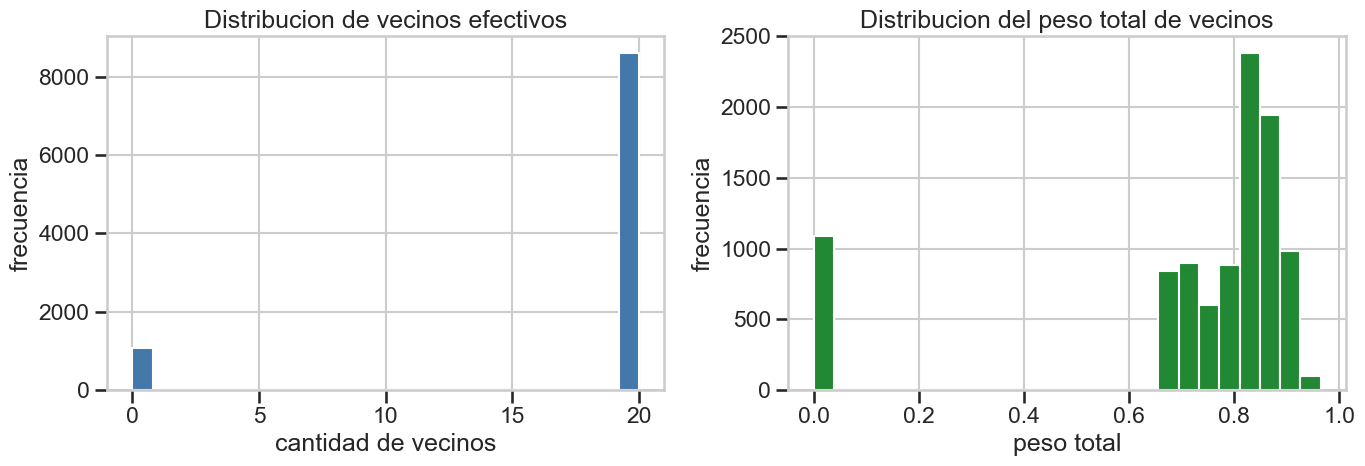

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    degree_df["effective_neighbors"], bins=25, color="#4477AA", edgecolor="white"
)
axes[0].set_title("Distribucion de vecinos efectivos")
axes[0].set_xlabel("cantidad de vecinos")
axes[0].set_ylabel("frecuencia")

axes[1].hist(
    degree_df["total_neighbor_weight"], bins=25, color="#228833", edgecolor="white"
)
axes[1].set_title("Distribucion del peso total de vecinos")
axes[1].set_xlabel("peso total")
axes[1].set_ylabel("frecuencia")

plt.tight_layout()
plt.show()

La distribución muestra que el grafo no quedó uniformemente conectado. La mayoría de las películas alcanza el máximo de vecinos permitido por el esquema `top-k`, mientras que una fracción menor permanece aislada. Esto indica que la construcción del grafo logra buena conectividad para gran parte del catálogo, aunque todavía deja nodos sin contexto estructural. En los nodos conectados, el peso total asignado a vecinos suele ser alto, lo que favorece la propagación de información en la GNN.


Antes de entrenar, conviene mirar que ve el modelo alrededor del target.

La tabla siguiente muestra las peliculas mas cercanas segun el score estructural del grafo disperso.

In [75]:
neighbor_rows = []
for neighbor_index, score in neighbor_scores[target_index]:
    neighbor_rows.append({
        "title": catalog.loc[neighbor_index, "title"],
        "genres": catalog.loc[neighbor_index, "genres"],
        "decade": catalog.loc[neighbor_index, "decade"],
        "avg_rating": catalog.loc[neighbor_index, "avg_rating"],
        "rating_count": catalog.loc[neighbor_index, "rating_count"],
        "structural_score": score,
    })


In [76]:
neighbor_frame = pd.DataFrame(neighbor_rows).sort_values(
    "structural_score", ascending=False
)

In [77]:
display(neighbor_frame.head(12).round(3))

,title,genres,decade,avg_rating,rating_count,structural_score
0,Fight Club (1999),Action|Crime|Drama|Thriller,1990,4.273,218,1.850
1,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,2000,3.982,109,1.677
2,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1990,4.197,307,1.212
3,Memento (2000),Mystery|Thriller,2000,4.123,159,1.131
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1990,4.238,204,1.076
5,Blade Runner (1982),Action|Sci-Fi|Thriller,1980,4.101,124,0.984
6,Interstellar (2014),Sci-Fi|IMAX,2010,3.993,73,0.924
7,Shutter Island (2010),Drama|Mystery|Thriller,2010,4.022,67,0.905
8,Saw (2004),Horror|Mystery|Thriller,2000,3.182,33,0.897
9,Primal Fear (1996),Crime|Drama|Mystery|Thriller,1990,3.643,35,0.890


Hasta acá trabajamos con una representación estructural entre películas. Ahora pasamos al grafo que realmente usa el modelo relacional: un **knowledge graph heterogéneo**, con nodos y relaciones tipadas. Esto permite separar explícitamente películas, géneros, tags, directores, keywords y anchors aprendidos dentro de una misma estructura.


Ahora vamos a construir el grafo de conocimiento.

Relaciones simbolicas:

- `has_genre(movie, genre)`
- `released_in_decade(movie, decade)`
- `has_tag(movie, tag)` para tags frecuentes
- `directed_by(movie, director)` si hay TMDb
- `has_keyword(movie, keyword)` si usamos metadata de TMDb

Relaciones aprendidas:

- `is_recommended(movie, Recommended)`
- `is_high_rating(movie, HighRating)`
- `is_popular(movie, Popular)`

En el grafo observado ocultamos las relaciones aprendidas positivas del target.


In [78]:
hetero_catalog = catalog.copy()

In [79]:
def ensure_list_value(value):
    # Esta función se asegura de que el valor sea una lista limpia, incluso si originalmente es un solo valor o NaN.
    if isinstance(value, list):
        return [item for item in value if pd.notna(item) and str(item).strip()]
    if isinstance(value, (tuple, set)):
        return [item for item in value if pd.notna(item) and str(item).strip()]
    if pd.isna(value):
        return []
    return [value]

In [80]:
list_columns = ["tmdb_keywords", "cast_names", "writer_names", "countries"]
for column_name in list_columns: # Aseguramos que las columnas de listas estén en el formato correcto, incluso si originalmente contienen valores únicos o NaN.
    if column_name not in hetero_catalog.columns:
        hetero_catalog[column_name] = [[] for _ in range(len(hetero_catalog))]
    else:
        hetero_catalog[column_name] = hetero_catalog[column_name].apply(
            ensure_list_value
        )

In [81]:
scalar_columns = ["director", "original_language", "runtime_bucket"]
for column_name in scalar_columns: # Aseguramos que las columnas escalares estén presentes y tengan valores NaN donde falten.
    if column_name not in hetero_catalog.columns:
        hetero_catalog[column_name] = pd.NA

In [82]:
hetero_catalog["movieId"] = hetero_catalog["movieId"].astype(int)

In [83]:
node_type_values = OrderedDict()

node_type_values["movie"] = ( # Creamos el diccionario de nodos de tipo "movie" con su movieId y título, asegurándonos de eliminar duplicados y ordenar por movieId.
    hetero_catalog[["movieId", "title"]]
    .drop_duplicates()
    .sort_values("movieId")
    .to_dict("records")
)

In [84]:
node_type_values["genre"] = (
    sorted(  # Creamos el conjunto de géneros únicos para el tipo de nodo "genre", asegurándonos de eliminar el género "(no genres listed)" y ordenar alfabéticamente.
        {
            genre
            for genres in hetero_catalog["genres_list"]
            for genre in genres
            if genre != "(no genres listed)"
        }
    )
)

In [85]:
node_type_values["decade"] = (
    sorted(  # Creamos el conjunto de décadas únicas para el tipo de nodo "decade", formateando las décadas como strings con el formato "1990s", "2000s", etc., y ordenándolas cronológicamente.
        {
            f"{int(decade)}s"
            for decade in hetero_catalog["decade"].dropna().unique().tolist()
        }
    )
)

In [86]:
node_type_values["tag"] = sorted(set(top_tags))

In [87]:
node_type_values["director"] = sorted( # Creamos el conjunto de directores únicos para el tipo de nodo "director", asegurándonos de eliminar valores nulos, convertir a string, eliminar espacios en blanco y ordenar alfabéticamente.
    {
        director
        for director in hetero_catalog["director"].dropna().astype(str).tolist()
        if director.strip()
    }
)

In [88]:
node_type_values["keyword"] = sorted( # Creamos el conjunto de keywords únicos para el tipo de nodo "keyword", asegurándonos de eliminar valores nulos, convertir a string, eliminar espacios en blanco y ordenar alfabéticamente.
    {
        keyword
        for keywords in hetero_catalog["tmdb_keywords"]
        for keyword in keywords
        if str(keyword).strip()
    }
)

In [89]:
node_type_values["actor"] = sorted( # Creamos el conjunto de actores únicos para el tipo de nodo "actor", asegurándonos de eliminar valores nulos, convertir a string, eliminar espacios en blanco y ordenar alfabéticamente.
    {
        actor
        for actors in hetero_catalog["cast_names"]
        for actor in actors
        if str(actor).strip()
    }
)

In [90]:
node_type_values["writer"] = sorted( # Creamos el conjunto de escritores únicos para el tipo de nodo "writer", asegurándonos de eliminar valores nulos, convertir a string, eliminar espacios en blanco y ordenar alfabéticamente.
    {
        writer
        for writers in hetero_catalog["writer_names"]
        for writer in writers
        if str(writer).strip()
    }
)

In [91]:
node_type_values["country"] = sorted(
    {
        country
        for countries in hetero_catalog["countries"]
        for country in countries
        if str(country).strip()
    }
)

In [92]:
node_type_values["language"] = sorted( # Creamos el conjunto de idiomas únicos para el tipo de nodo "language", asegurándonos de eliminar valores nulos, convertir a string, eliminar espacios en blanco y ordenar alfabéticamente.
    {
        language
        for language in hetero_catalog["original_language"]
        .dropna()
        .astype(str)
        .tolist()
        if language.strip()
    }
)

In [93]:
node_type_values["runtime_bucket"] = sorted(
    {
        bucket
        for bucket in hetero_catalog["runtime_bucket"].dropna().astype(str).tolist()
        if bucket.strip()
    }
)

In [94]:
node_type_values["anchor"] = [spec["anchor"] for spec in TASK_SPECS.values()]

In [95]:
node_lookup = {}
node_records = []
global_id = 0

for movie_row in node_type_values["movie"]:
    movie_id = int(movie_row["movieId"])
    node_lookup[("movie", movie_id)] = global_id
    node_records.append(
        {
            "global_id": global_id,
            "node_type": "movie",
            "node_key": movie_id,
            "label": movie_row["title"],
        }
    )
    global_id += 1

for node_type in [
    "genre",
    "decade",
    "tag",
    "director",
    "keyword",
    "actor",
    "writer",
    "country",
    "language",
    "runtime_bucket",
    "anchor",
]:
    for value in node_type_values[node_type]:
        node_lookup[(node_type, value)] = global_id
        node_records.append(
            {
                "global_id": global_id,
                "node_type": node_type,
                "node_key": value,
                "label": value,
            }
        )
        global_id += 1

In [96]:
node_df = pd.DataFrame(node_records)

In [97]:
display(node_df.head(15))

,global_id,node_type,node_key,label
0,0,movie,1,Toy Story (1995)
1,1,movie,2,Jumanji (1995)
2,2,movie,3,Grumpier Old Men (1995)
3,3,movie,4,Waiting to Exhale (1995)
4,4,movie,5,Father of the Bride Part II (1995)
5,5,movie,6,Heat (1995)
6,6,movie,7,Sabrina (1995)
7,7,movie,8,Tom and Huck (1995)
8,8,movie,9,Sudden Death (1995)
9,9,movie,10,GoldenEye (1995)


In [98]:
print("Nodos totales:", len(node_df))
display(
    node_df["node_type"]
    .value_counts()
    .rename_axis("node_type")
    .reset_index(name="count")
)

Nodos totales: 69350


,node_type,count
0,actor,30138
1,keyword,17147
2,movie,9724
3,writer,8078
4,director,3969
5,country,108
6,tag,100
7,language,48
8,genre,19
9,decade,13


In [99]:
edge_records = []


def add_edge(src_type, src_key, relation, dst_type, dst_key, source):
    src_id = node_lookup.get((src_type, src_key))
    dst_id = node_lookup.get((dst_type, dst_key))
    if src_id is None or dst_id is None:
        return

    edge_records.append(
        {
            "src_type": src_type,
            "src_key": src_key,
            "src_id": src_id,
            "relation": relation,
            "dst_type": dst_type,
            "dst_key": dst_key,
            "dst_id": dst_id,
            "source": source,
        }
    )

In [100]:
for _, row in hetero_catalog.iterrows():
    movie_id = int(row["movieId"])

    for genre in row["genres_list"]:
        if genre != "(no genres listed)":
            add_edge("movie", movie_id, "has_genre", "genre", genre, "movielens")

    if pd.notna(row["decade"]):
        add_edge(
            "movie",
            movie_id,
            "released_in_decade",
            "decade",
            f"{int(row['decade'])}s",
            "movielens",
        )

    for tag in row["tags_list"]:
        if tag in top_tags:
            add_edge("movie", movie_id, "has_tag", "tag", tag, "movielens")

    if pd.notna(row["director"]):
        add_edge("movie", movie_id, "directed_by", "director", row["director"], "tmdb")

    for keyword in row["tmdb_keywords"]:
        add_edge("movie", movie_id, "has_keyword", "keyword", keyword, "tmdb")

    for actor in row["cast_names"][:5]:
        add_edge("movie", movie_id, "acted_by", "actor", actor, "tmdb")

    for writer in row["writer_names"][:3]:
        add_edge("movie", movie_id, "written_by", "writer", writer, "tmdb")

    for country in row["countries"]:
        add_edge("movie", movie_id, "produced_in_country", "country", country, "tmdb")

    if pd.notna(row["original_language"]):
        add_edge(
            "movie",
            movie_id,
            "original_language",
            "language",
            row["original_language"],
            "tmdb",
        )

    if pd.notna(row["runtime_bucket"]):
        add_edge(
            "movie",
            movie_id,
            "has_runtime_bucket",
            "runtime_bucket",
            row["runtime_bucket"],
            "derived",
        )

    for task_name, spec in TASK_SPECS.items():
        if int(row[task_name]) == 1:
            add_edge(
                "movie", movie_id, spec["relation"], "anchor", spec["anchor"], "derived"
            )

In [101]:
target_movie_id = int(target_row["movieId"])

In [102]:
hidden_edge_keys = {
    ("movie", target_movie_id, spec["relation"], "anchor", spec["anchor"])
    for task_name, spec in TASK_SPECS.items()
    if int(target_row[task_name]) == 1
}

In [103]:
edges_full_df = pd.DataFrame(edge_records)

In [104]:
edges_observed_df = edges_full_df.loc[
    ~edges_full_df.apply(
        lambda row: (
            row["src_type"],
            row["src_key"],
            row["relation"],
            row["dst_type"],
            row["dst_key"],
        )
        in hidden_edge_keys,
        axis=1,
    )
].reset_index(drop=True)

In [105]:
print("Triples completas:", len(edges_full_df))
print("Triples observadas:", len(edges_observed_df))
print("Enlaces ocultos:", hidden_edge_keys)
print("Entidades unicas:", len(node_df))
print("Peliculas en las entidades:", len(node_type_values["movie"]))

Triples completas: 248904
Triples observadas: 248901
Enlaces ocultos: {('movie', 79132, 'is_high_rating', 'anchor', 'HighRating'), ('movie', 79132, 'is_popular', 'anchor', 'Popular'), ('movie', 79132, 'is_recommended', 'anchor', 'Recommended')}
Entidades unicas: 69350
Peliculas en las entidades: 9724


In [106]:
def build_sparse_relation_adjacency(edge_frame, num_nodes):
    # Esta función construye un diccionario de matrices de adyacencia dispersas para cada tipo de relación, incluyendo la relación inversa, a partir del DataFrame de bordes y el número total de nodos.
    relation_adjacency = {}

    for relation_name, relation_rows in edge_frame.groupby("relation"):
        src = torch.tensor(relation_rows["src_id"].to_numpy(), dtype=torch.long)
        dst = torch.tensor(relation_rows["dst_id"].to_numpy(), dtype=torch.long)
        values = torch.ones(len(relation_rows), dtype=torch.float32)

        row_degree = torch.zeros(num_nodes, dtype=torch.float32)
        row_degree.index_add_(0, src, values)
        normalized_values = values / row_degree[src].clamp_min(1.0)

        relation_adjacency[relation_name] = torch.sparse_coo_tensor(
            torch.stack([src, dst]),
            normalized_values,
            size=(num_nodes, num_nodes),
        ).coalesce()

        rev_row_degree = torch.zeros(num_nodes, dtype=torch.float32)
        rev_row_degree.index_add_(0, dst, values)
        rev_normalized_values = values / rev_row_degree[dst].clamp_min(1.0)

        relation_adjacency[f"rev_{relation_name}"] = torch.sparse_coo_tensor(
            torch.stack([dst, src]),
            rev_normalized_values,
            size=(num_nodes, num_nodes),
        ).coalesce()

    return relation_adjacency

In [107]:
relation_adjacency_full = build_sparse_relation_adjacency(edges_full_df, len(node_df))
relation_adjacency_observed = build_sparse_relation_adjacency(
    edges_observed_df, len(node_df)
)

In [108]:
print("Relaciones disponibles:", len(relation_adjacency_observed))
print(sorted(relation_adjacency_observed.keys())[:20])

Relaciones disponibles: 26
['acted_by', 'directed_by', 'has_genre', 'has_keyword', 'has_runtime_bucket', 'has_tag', 'is_high_rating', 'is_popular', 'is_recommended', 'original_language', 'produced_in_country', 'released_in_decade', 'rev_acted_by', 'rev_directed_by', 'rev_has_genre', 'rev_has_keyword', 'rev_has_runtime_bucket', 'rev_has_tag', 'rev_is_high_rating', 'rev_is_popular']


El knowledge graph resultante ya tiene una escala considerable: decenas de miles de entidades y cientos de miles de triples. Sin embargo, el experimento que hacemos es local y controlado: ocultamos únicamente las relaciones aprendidas positivas del target y evaluamos si el sistema híbrido puede recuperarlas usando la información restante del grafo.


In [109]:
LEARNED_RELATIONS = {spec["relation"] for spec in TASK_SPECS.values()}

In [110]:
edges_model_df = edges_observed_df.loc[
    ~edges_observed_df["relation"].isin(LEARNED_RELATIONS)
].reset_index(drop=True)

In [111]:
relation_adjacency_model = build_sparse_relation_adjacency(edges_model_df, len(node_df))

In [112]:
print("Relaciones para entrenamiento:", sorted(edges_model_df["relation"].unique()))
print("Cantidad de triples para training graph:", len(edges_model_df))

Relaciones para entrenamiento: ['acted_by', 'directed_by', 'has_genre', 'has_keyword', 'has_runtime_bucket', 'has_tag', 'original_language', 'produced_in_country', 'released_in_decade', 'written_by']
Cantidad de triples para training graph: 240395


Para evitar una solución trivial, la GNN no recibe como aristas de entrada las relaciones aprendidas `is_recommended`, `is_high_rating` e `is_popular`. Esas relaciones se usan como objetivos de predicción, pero se eliminan del grafo de entrenamiento. De este modo, el modelo no puede memorizar directamente esos enlaces y debe inferirlos a partir del resto de la estructura del knowledge graph.


Armemos un sistema hibrido:

In [113]:
NEURAL_EDGE_RELATIONS = ["directed_by", "has_keyword"]

In [114]:
candidate_node_ids_by_type = { # Creamos un diccionario que mapea cada tipo de nodo a un tensor de IDs globales correspondientes a ese tipo de nodo, utilizando el DataFrame de nodos.
    node_type: torch.tensor(
        node_df.loc[node_df["node_type"] == node_type, "global_id"].to_numpy(),
        dtype=torch.long,
    )
    for node_type in node_df["node_type"].unique()
}

In [115]:
positive_edge_tensors = {}
positive_edge_sets = {}
for relation_name in NEURAL_EDGE_RELATIONS:
    rel_df = edges_observed_df.loc[
        edges_observed_df["relation"] == relation_name, ["src_id", "dst_id"]
    ].drop_duplicates()

    positive_edge_tensors[relation_name] = torch.tensor(
        rel_df.to_numpy(), dtype=torch.long
    )
    positive_edge_sets[relation_name] = set(map(tuple, rel_df.to_numpy().tolist()))

In [116]:
RELATION_SCHEMA = {
    "has_genre": ("movie", "genre"),
    "released_in_decade": ("movie", "decade"),
    "has_tag": ("movie", "tag"),
    "directed_by": ("movie", "director"),
    "has_keyword": ("movie", "keyword"),
    "acted_by": ("movie", "actor"),
    "written_by": ("movie", "writer"),
    "produced_in_country": ("movie", "country"),
    "original_language": ("movie", "language"),
    "has_runtime_bucket": ("movie", "runtime_bucket"),
    "is_recommended": ("movie", "anchor"),
    "is_high_rating": ("movie", "anchor"),
    "is_popular": ("movie", "anchor"),
}

In [117]:
def build_relation_index_from_edges(edge_frame):
    # Esta función construye un índice de relaciones a partir del DataFrame de bordes, organizando los destinos por fuente y tipo de relación, e incluyendo las relaciones inversas para facilitar el acceso durante el entrenamiento.
    relation_index = {}
    for _, row in edge_frame.iterrows():
        src_id = int(row["src_id"])
        dst_id = int(row["dst_id"])
        relation_name = row["relation"]

        relation_index.setdefault(relation_name, {}).setdefault(src_id, set()).add(
            dst_id
        )
        relation_index.setdefault(f"rev_{relation_name}", {}).setdefault(
            dst_id, set()
        ).add(src_id)
    return relation_index

In [118]:
relation_index_full = build_relation_index_from_edges(edges_full_df)
relation_index_observed = build_relation_index_from_edges(edges_observed_df)

In [119]:
movie_global_ids = [
    node_lookup[("movie", int(movie_id))] for movie_id in hetero_catalog["movieId"]
]
movie_titles = hetero_catalog["title"].tolist()
movie_ids = hetero_catalog["movieId"].tolist()

In [120]:
title_counts = hetero_catalog["title"].value_counts().to_dict()
movie_display_labels = [
    f"{title} [movieId={movie_id}]" if title_counts.get(title, 0) > 1 else title
    for title, movie_id in zip(movie_titles, movie_ids)
]

In [121]:
movie_global_id_to_label = dict(zip(movie_global_ids, movie_display_labels))
movie_global_id_to_title = dict(zip(movie_global_ids, movie_titles))
movie_title_to_global_ids = {}
for global_id, title in zip(movie_global_ids, movie_titles):
    movie_title_to_global_ids.setdefault(title, []).append(global_id)

In [122]:
reverse_relation_to_task = {
    f"rev_{spec['relation']}": task_name for task_name, spec in TASK_SPECS.items()
}
task_index_lookup = {
    task_name: index for index, task_name in enumerate(TASK_SPECS.keys())
}

In [123]:
typed_label_to_id = {}
for _, row in node_df.iterrows():
    node_type = row["node_type"]
    node_label = str(row["label"])
    global_id = int(row["global_id"])
    typed_label_to_id.setdefault(node_type, {})
    typed_label_to_id[node_type][node_label] = global_id

In [124]:
def resolve_entity_node_id(node_type, entity_value): # Esta función resuelve el ID global de un nodo dado su tipo y valor, 
    # utilizando el diccionario de mapeo creado a partir del DataFrame de nodos, 
    # y lanzando errores claros si el tipo de nodo o el valor no son encontrados.
    entity_value = str(entity_value)

    if node_type not in typed_label_to_id:
        raise KeyError(f"Tipo de nodo no soportado: {node_type}")

    if entity_value not in typed_label_to_id[node_type]:
        raise KeyError(
            f"No encontre la entidad '{entity_value}' para el tipo '{node_type}'"
        )

    return typed_label_to_id[node_type][entity_value]


def one_hot_set(node_type, entity_value): # Esta función genera un vector one-hot para una entidad dada su tipo 
    # y valor, utilizando la función de resolución de ID para encontrar el índice correspondiente en el vector,
    # y asegurándose de que el vector tenga la longitud correcta basada en el número total de nodos.
    vector = np.zeros(len(node_df), dtype=float)
    node_id = resolve_entity_node_id(node_type, entity_value)
    vector[node_id] = 1.0
    return vector


def symbolic_project(score_vector, relation_name, relation_index): # Esta función proyecta un vector de puntuaciones 
    #a través de una relación simbólica utilizando el índice de relaciones,
    output = np.zeros(len(node_df), dtype=float)

    active_node_ids = np.where(score_vector > 0)[0]
    for src_id in active_node_ids:
        tails = relation_index.get(relation_name, {}).get(int(src_id), set())
        for dst_id in tails:
            output[dst_id] = max(output[dst_id], score_vector[src_id])

    return output

In [125]:
def conjunction(x, y): # Esta función calcula la conjunción lógica suave entre dos vectores de puntuaciones,
    return x * y


def disjunction(x, y): # Esta función calcula la disyunción lógica suave entre dos vectores de puntuaciones,
    # utilizando la fórmula de probabilidad de unión para evitar que el resultado exceda 1.
    return x + y - x * y


def negation(x): # Esta función calcula la negación lógica suave de un vector de puntuaciones,
    return 1 - x

In [126]:
def summarize_scores(
    score_vector, top_k=5, threshold=0.03
):  # Esta función resume un vector de puntuaciones para películas,
    # seleccionando las películas con puntuaciones por encima de un umbral y mostrando sus etiquetas
    # y puntuaciones formateadas, ordenadas de mayor a menor, y limitando el número de resultados mostrados a top_k.
    rows = [
        (
            movie_global_id_to_label[movie_global_id],
            float(score_vector[movie_global_id]),
        )
        for movie_global_id in movie_global_ids
    ]
    rows = sorted(rows, key=lambda item: item[1], reverse=True)
    rows = [row for row in rows if row[1] >= threshold][:top_k]
    return (
        ", ".join(f"{label}: {score:.3f}" for label, score in rows)
        if rows
        else "sin candidatos fuertes"
    )

Vamos definiendo las inputs del modelo:

In [127]:
movie_feature_matrix = X.clone()

In [128]:
movie_node_ids = torch.tensor(
    [node_lookup[("movie", int(movie_id))] for movie_id in hetero_catalog["movieId"]],
    dtype=torch.long,
)

In [129]:
# relation_names = sorted(relation_adjacency_observed.keys())
relation_names = sorted(relation_adjacency_model.keys())

In [130]:
Y = torch.tensor(hetero_catalog[list(TASK_SPECS.keys())].values, dtype=torch.float32)
train_mask = torch.ones(len(hetero_catalog), dtype=torch.bool)
train_mask[target_index] = False

In [ ]:
print("movie_feature_matrix:", movie_feature_matrix.shape)
print("movie_node_ids:", movie_node_ids.shape)
print("labels:", Y.shape)
print("cantidad de relaciones:", len(relation_names))

movie_feature_matrix: torch.Size([9724, 228])
movie_node_ids: torch.Size([9724])
labels: torch.Size([9724, 3])
cantidad de relaciones: 20


Pasamos al device:

In [132]:
movie_feature_matrix = movie_feature_matrix.to(device)
movie_node_ids = movie_node_ids.to(device)
Y = Y.to(device)
train_mask = train_mask.to(device)

In [133]:
# relation_adjacency_observed = { # Movemos las matrices de adyacencia de relaciones observadas, modelo 
#     #y completas al dispositivo seleccionado (CPU o GPU) para su uso eficiente durante el entrenamiento del modelo de GNN.
#     relation_name: adj.to(device)
#     for relation_name, adj in relation_adjacency_observed.items()
# }

relation_adjacency_model = { # Movemos las matrices de adyacencia de relaciones del modelo 
    # al dispositivo seleccionado (CPU o GPU) para su uso eficiente durante el entrenamiento del modelo de GNN.
    relation_name: adj.to(device)
    for relation_name, adj in relation_adjacency_model.items()
}

relation_adjacency_full = { # Movemos las matrices de adyacencia de relaciones completas al dispositivo 
    # seleccionado (CPU o GPU) para su uso eficiente durante el análisis y comparación con el modelo de GNN.
    relation_name: adj.to(device)
    for relation_name, adj in relation_adjacency_full.items()
}

In [134]:
candidate_node_ids_by_type = {
    node_type: tensor.to(device)
    for node_type, tensor in candidate_node_ids_by_type.items()
}

positive_edge_tensors = {
    relation_name: tensor.to(device)
    for relation_name, tensor in positive_edge_tensors.items()
}

### Training

A partir de este punto la GNN ya no opera sobre una sola matriz de adyacencia entre películas, sino sobre un conjunto de matrices por relación del knowledge graph heterogéneo. Los nodos de tipo `movie` reciben features explícitas del catálogo, mientras que el message passing se realiza sobre todo el grafo.

El entrenamiento combina dos objetivos:

- una salida **multitarea** sobre películas para predecir `is_recommended`, `is_high_rating` e `is_popular`,
- y una pérdida auxiliar de **link prediction** sobre algunas relaciones del KG, en este caso `directed_by` y `has_keyword`.

La idea es que el modelo no solo aprenda etiquetas latentes sobre películas, sino también proyecciones neuronales útiles para completar ciertas relaciones del grafo cuando la información observada es incompleta.




Definimos el modelo:

In [135]:
class RelationalGraphConv(nn.Module):
    # Esta clase implementa una capa de convolución gráfica relacional que actualiza las representaciones de los nodos 
    # en función de sus características y las relaciones con sus vecinos, 
    # utilizando transformaciones lineales específicas para cada tipo de relación 
    # y aplicando una función de activación ReLU seguida de dropout para regularización.
    def __init__(self, input_dim, output_dim, relation_names, dropout=0.1):
        super().__init__()
        self.self_loop = nn.Linear(input_dim, output_dim, bias=False)
        self.relation_transforms = nn.ModuleDict(
            {
                relation_name: nn.Linear(input_dim, output_dim, bias=False)
                for relation_name in relation_names
            }
        )
        self.bias = nn.Parameter(torch.zeros(output_dim))
        self.dropout = dropout

    def forward(self, x, relation_adjacency):
        out = self.self_loop(x)

        for relation_name, adj in relation_adjacency.items():
            transformed = self.relation_transforms[relation_name](x)
            out = out + torch.sparse.mm(adj, transformed)

        out = out + self.bias
        out = torch.relu(out)
        out = F.dropout(out, p=self.dropout, training=self.training)
        return out

In [136]:
class HeteroMovieRGCN(nn.Module):
    # Esta clase implementa un modelo de Red Neuronal de Convolución Gráfica Relacional para el conjunto de datos de películas,
    # que incluye capas de convolución gráfica relacional para actualizar las representaciones de los nodos,
    # proyecciones lineales para las características de los nodos y las películas, y una capa de salida para generar 
    # las predicciones de las tareas, además de manejar relaciones adicionales con embeddings específicos para cada tipo de relación.
    def __init__(
        self,
        num_nodes,
        movie_node_ids,
        movie_input_dim,
        output_dim,
        relation_names,
        hidden_dim=64,
        node_emb_dim=32,
        dropout=0.1,
        edge_relation_names=None,
    ):
        super().__init__()
        self.node_embeddings = nn.Embedding(num_nodes, node_emb_dim)
        self.node_input_proj = nn.Linear(node_emb_dim, hidden_dim)
        self.movie_input_proj = nn.Linear(movie_input_dim, hidden_dim)

        self.conv1 = RelationalGraphConv(
            hidden_dim, hidden_dim, relation_names, dropout=dropout
        )
        self.conv2 = RelationalGraphConv(
            hidden_dim, hidden_dim, relation_names, dropout=dropout
        )

        self.out = nn.Linear(hidden_dim, output_dim)

        edge_relation_names = edge_relation_names or []
        self.edge_relation_to_id = {
            name: idx for idx, name in enumerate(edge_relation_names)
        }
        self.edge_relation_embeddings = nn.Embedding(
            max(1, len(edge_relation_names)), hidden_dim
        )

        self.register_buffer("movie_node_ids", movie_node_ids)

    def forward(self, movie_features, relation_adjacency):
        x = self.node_input_proj(self.node_embeddings.weight)

        movie_x = self.movie_input_proj(movie_features)
        x = x.clone()
        x[self.movie_node_ids] = x[self.movie_node_ids] + movie_x

        h1 = self.conv1(x, relation_adjacency)
        h2 = self.conv2(h1, relation_adjacency)
        h = h1 + h2

        movie_h = h[self.movie_node_ids]
        logits = self.out(movie_h)
        return logits, h, movie_h

    def score_edges(self, node_embeddings, relation_name, src_ids, dst_ids):
        rel_id = self.edge_relation_to_id[relation_name]
        rel_vec = self.edge_relation_embeddings.weight[rel_id]
        src = node_embeddings[src_ids]
        dst = node_embeddings[dst_ids]
        return (src * rel_vec * dst).sum(dim=-1)

La arquitectura elegida es deliberadamente simple. No buscamos el modelo más potente posible, sino una GNN lo suficientemente clara como para ver cómo la información se propaga entre películas y cómo esa representación se usa luego para predecir varias relaciones aprendidas en paralelo.


In [141]:
EPOCHS = 200
LR = 1e-3
HIDDEN_DIM = 64

In [144]:
model = HeteroMovieRGCN(
    num_nodes=len(node_df),
    movie_node_ids=movie_node_ids,
    movie_input_dim=movie_feature_matrix.shape[1],
    output_dim=Y.shape[1],
    relation_names=relation_names,
    hidden_dim=64,
    node_emb_dim=32,
    dropout=0.10,
    edge_relation_names=NEURAL_EDGE_RELATIONS,
)
model = model.to(device)

In [145]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1 * LR)
criterion = nn.BCEWithLogitsLoss()

In [146]:
EDGE_LOSS_WEIGHT = 0.25
MAX_EDGE_SAMPLES = 2048


def sample_negative_edges( # Esta función muestrea bordes negativos para entrenamiento de enlaces, dado un conjunto de bordes positivos, 
    # candidatos de destino, pares prohibidos y el número deseado de muestras, 
    # asegurándose de que los bordes negativos generados no estén en el conjunto de bordes positivos ni en los pares prohibidos,
    # y devolviendo un tensor de bordes negativos con el formato adecuado para su uso en el entrenamiento del modelo de GNN.
    positive_edges, candidate_dst_ids, forbidden_pairs, num_samples
):
    if len(positive_edges) == 0:
        return torch.empty((0, 2), dtype=torch.long, device=device)

    negatives = []
    while len(negatives) < num_samples:
        src = int(positive_edges[torch.randint(len(positive_edges), (1,))][0, 0].item())
        dst = int(candidate_dst_ids[torch.randint(len(candidate_dst_ids), (1,))].item())
        if (src, dst) not in forbidden_pairs:
            negatives.append((src, dst))

    return torch.tensor(negatives, dtype=torch.long, device=device)

In [148]:
progress_bar = tqdm(range(EPOCHS), desc="Training R-GCN")
history = []
for epoch in progress_bar:
    logits, node_embeddings, movie_embeddings = model(
        movie_feature_matrix, relation_adjacency_model
    )
    task_loss = criterion(logits[train_mask], Y[train_mask])

    edge_losses = []
    for relation_name in NEURAL_EDGE_RELATIONS:
        pos_edges = positive_edge_tensors[relation_name]
        if len(pos_edges) == 0:
            continue

        sample_size = min(len(pos_edges), MAX_EDGE_SAMPLES)
        pos_batch = pos_edges[torch.randperm(len(pos_edges))[:sample_size]]

        dst_type = RELATION_SCHEMA[relation_name][1]
        neg_batch = sample_negative_edges(
            pos_batch,
            candidate_node_ids_by_type[dst_type],
            positive_edge_sets[relation_name],
            sample_size,
        )

        pos_logits = model.score_edges(
            node_embeddings, relation_name, pos_batch[:, 0], pos_batch[:, 1]
        )
        neg_logits = model.score_edges(
            node_embeddings, relation_name, neg_batch[:, 0], neg_batch[:, 1]
        )

        edge_loss = F.binary_cross_entropy_with_logits(
            torch.cat([pos_logits, neg_logits], dim=0),
            torch.cat(
                [torch.ones_like(pos_logits), torch.zeros_like(neg_logits)], dim=0
            ),
        )
        edge_losses.append(edge_loss)

    aux_loss = (
        torch.stack(edge_losses).mean()
        if edge_losses
        else torch.tensor(0.0, device=task_loss.device)
    )
    loss = task_loss + EDGE_LOSS_WEIGHT * aux_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        row = {"epoch": epoch, "loss": float(loss.item())}

        for task_index, task_name in enumerate(TASK_SPECS):
            task_train_acc = (
                (
                    (probs[train_mask, task_index] >= 0.5).float()
                    == Y[train_mask, task_index]
                )
                .float()
                .mean()
                .item()
            )
            row[f"{task_name}_train_acc"] = float(task_train_acc)
            row[f"target_{task_name}_prob"] = float(
                probs[target_index, task_index].item()
            )

        history.append(row)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            rec=f"{row['target_recommended_prob']:.3f}",
            hr=f"{row['target_high_rating_prob']:.3f}",
            pop=f"{row['target_popular_prob']:.3f}",
        )

Training R-GCN:   0%|          | 0/200 [00:00<?, ?it/s]

In [149]:
# Guardar el modelo
torch.save(model.state_dict(), "./Data/Model/hetero_movie_rgcn.pth")

In [150]:
history_df = pd.DataFrame(history)
# Guardar el historial de entrenamiento en un archivo CSV para análisis posterior
history_df.to_csv("./Data/training_history.csv", index=False)

In [151]:
history_df.tail()

,epoch,loss,recommended_train_acc,target_recommended_prob,high_rating_train_acc,target_high_rating_prob,popular_train_acc,target_popular_prob
195,195,0.145226,0.979944,1.000000,0.969762,0.999736,0.986218,0.999740
196,196,0.147833,0.978813,0.999999,0.967088,0.999874,0.988378,0.998257
197,197,0.144358,0.981179,0.999998,0.968528,0.999511,0.987144,0.992361
198,198,0.145286,0.977887,0.999999,0.970791,0.999151,0.986424,0.999709
199,199,0.142033,0.980356,0.999986,0.971408,0.983353,0.986013,0.996441


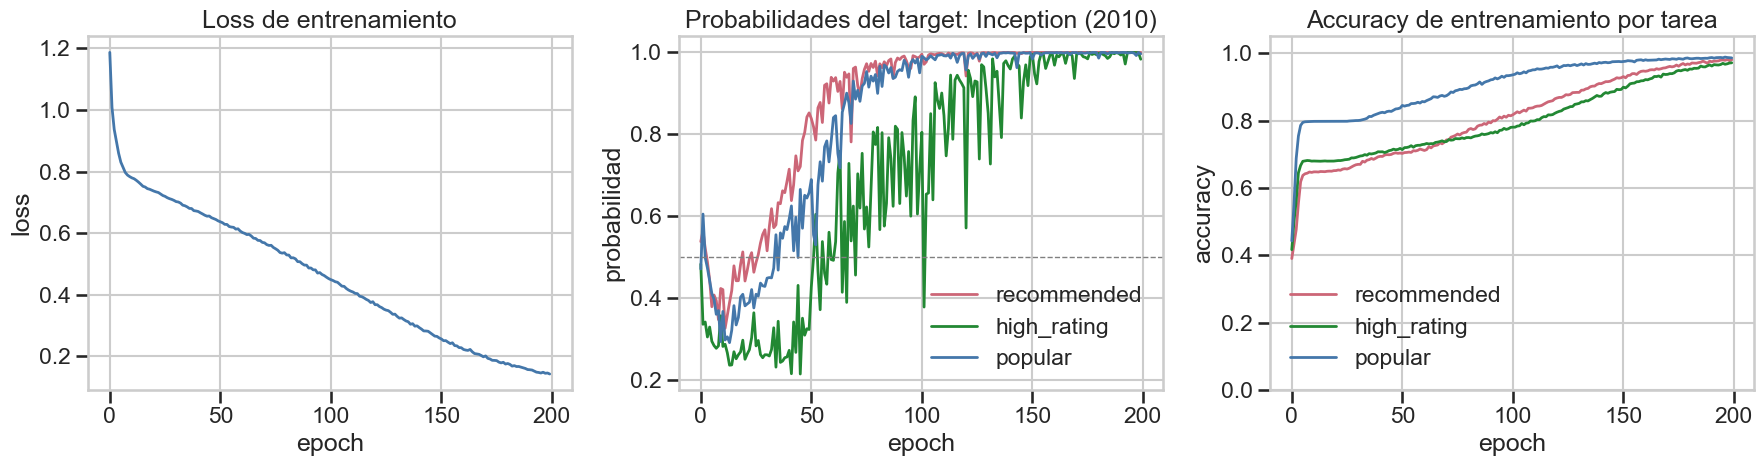

In [152]:
task_colors = {
    "recommended": "#CC6677",
    "high_rating": "#228833",
    "popular": "#4477AA",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["loss"], color="#4477AA", linewidth=2)
axes[0].set_title("Loss de entrenamiento")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

for task_name in TASK_SPECS.keys():
    axes[1].plot(
        history_df["epoch"],
        history_df[f"target_{task_name}_prob"],
        color=task_colors[task_name],
        linewidth=2,
        label=task_name,
    )
axes[1].axhline(0.5, linestyle="--", color="gray", linewidth=1)
axes[1].set_title(f"Probabilidades del target: {target_title}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("probabilidad")
axes[1].legend()

for task_name in TASK_SPECS.keys():
    axes[2].plot(
        history_df["epoch"],
        history_df[f"{task_name}_train_acc"],
        color=task_colors[task_name],
        linewidth=2,
        label=task_name,
    )
axes[2].set_title("Accuracy de entrenamiento por tarea")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("accuracy")
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

### Inferencia y Embeddings

#### Inferencia

Vamos a hacer la inferencia

In [153]:
# cargar el modelo guardado para evaluación o uso posterior
model = HeteroMovieRGCN(
    num_nodes=len(node_df),
    movie_node_ids=movie_node_ids,
    movie_input_dim=movie_feature_matrix.shape[1],
    output_dim=Y.shape[1],
    relation_names=relation_names,
    hidden_dim=64,
    node_emb_dim=32,
    dropout=0.10,
    edge_relation_names=NEURAL_EDGE_RELATIONS,
)
model.load_state_dict(torch.load("./Data/Model/hetero_movie_rgcn.pth", map_location=device))
model = model.to(device)
model.eval()


HeteroMovieRGCN(
  (node_embeddings): Embedding(69350, 32)
  (node_input_proj): Linear(in_features=32, out_features=64, bias=True)
  (movie_input_proj): Linear(in_features=228, out_features=64, bias=True)
  (conv1): RelationalGraphConv(
    (self_loop): Linear(in_features=64, out_features=64, bias=False)
    (relation_transforms): ModuleDict(
      (acted_by): Linear(in_features=64, out_features=64, bias=False)
      (directed_by): Linear(in_features=64, out_features=64, bias=False)
      (has_genre): Linear(in_features=64, out_features=64, bias=False)
      (has_keyword): Linear(in_features=64, out_features=64, bias=False)
      (has_runtime_bucket): Linear(in_features=64, out_features=64, bias=False)
      (has_tag): Linear(in_features=64, out_features=64, bias=False)
      (original_language): Linear(in_features=64, out_features=64, bias=False)
      (produced_in_country): Linear(in_features=64, out_features=64, bias=False)
      (released_in_decade): Linear(in_features=64, out_feat

In [154]:
with torch.no_grad():
    logits, node_embeddings, movie_embeddings = model(
        movie_feature_matrix, relation_adjacency_model
    )
    learned_probs = torch.sigmoid(logits)
    frozen_node_embeddings = node_embeddings.detach()

In [155]:
def learned_project(score_vector, relation_name): # Esta función proyecta un vector de puntuaciones a través de una relación neuronal aprendida,
     # utilizando las probabilidades aprendidas del modelo de GNN para la tarea correspondiente,
    # y combinándolas con el peso del nodo ancla para generar un nuevo vector de puntuaciones para las películas, 
    # asegurándose de manejar correctamente las relaciones inversas y los casos donde el peso del nodo ancla es cero o negativo.
    task_name = reverse_relation_to_task.get(relation_name)
    if task_name is None:
        raise ValueError(f"Relacion neuronal no soportada: {relation_name}")

    anchor_name = TASK_SPECS[task_name]["anchor"]
    anchor_node_id = node_lookup[("anchor", anchor_name)]
    anchor_weight = score_vector[anchor_node_id]

    output = np.zeros(len(node_df), dtype=float)
    if anchor_weight <= 0:
        return output

    task_index = task_index_lookup[task_name]
    for movie_position, movie_global_id in enumerate(movie_global_ids):
        output[movie_global_id] = anchor_weight * float(
            learned_probs[movie_position, task_index].item()
        )

    return output


def learned_relation_project(score_vector, relation_name): # Esta función proyecta un vector de puntuaciones 
    # a través de una relación neuronal aprendida entre nodos,
    # utilizando el modelo de GNN para calcular las puntuaciones de los bordes entre nodos fuente 
    # y destino basados en sus embeddings, y combinando estas puntuaciones con el vector de puntuaciones de entrada 
    # para generar un nuevo vector de puntuaciones para las películas,
    # asegurándose de manejar correctamente las relaciones inversas y 
    # los casos donde el vector de puntuaciones de entrada tiene valores cero o negativos.
    reverse = relation_name.startswith("rev_")
    base_relation = relation_name[4:] if reverse else relation_name

    if base_relation not in NEURAL_EDGE_RELATIONS:
        raise ValueError(f"Relacion neuronal no soportada: {relation_name}")

    if reverse:
        candidate_type = RELATION_SCHEMA[base_relation][0]
    else:
        candidate_type = RELATION_SCHEMA[base_relation][1]

    candidate_ids = candidate_node_ids_by_type[candidate_type]
    candidate_np = candidate_ids.detach().cpu().numpy()

    output = np.zeros(len(node_df), dtype=float)
    active_node_ids = np.where(score_vector > 0)[0]

    for source_id in active_node_ids:
        if reverse:
            src_ids = candidate_ids
            dst_ids = torch.full(
                (len(candidate_ids),),
                int(source_id),
                dtype=torch.long,
                device=candidate_ids.device,
            )
        else:
            src_ids = torch.full(
                (len(candidate_ids),),
                int(source_id),
                dtype=torch.long,
                device=candidate_ids.device,
            )
            dst_ids = candidate_ids

        scores = (
            torch.sigmoid(
                model.score_edges(
                    frozen_node_embeddings, base_relation, src_ids, dst_ids
                )
            )
            .detach()
            .cpu()
            .numpy()
        )

        output[candidate_np] = np.maximum(
            output[candidate_np], score_vector[source_id] * scores
        )

    return output


def hybrid_project(score_vector, relation_name, relation_index):
    # Esta función proyecta un vector de puntuaciones a través de una relación utilizando 
    # tanto la proyección simbólica basada en el índice de relaciones como la proyección neuronal aprendida del modelo de GNN,
    # combinando los resultados de ambas proyecciones mediante una disyunción lógica suave 
    # para generar un nuevo vector de puntuaciones para las películas, y manejando correctamente los casos donde la relación
    # es solo simbólica, solo neuronal o ambas.
    symbolic = symbolic_project(score_vector, relation_name, relation_index)

    if relation_name in reverse_relation_to_task:
        neural = learned_project(score_vector, relation_name)
        return disjunction(symbolic, neural)

    base_relation = (
        relation_name[4:] if relation_name.startswith("rev_") else relation_name
    )
    if base_relation in NEURAL_EDGE_RELATIONS:
        neural = learned_relation_project(score_vector, relation_name)
        return disjunction(symbolic, neural)

    return symbolic

In [156]:
prediction_frame = pd.DataFrame(
    {
        "movieId": hetero_catalog["movieId"],
        "title": hetero_catalog["title"],
        "genres": hetero_catalog["genres"],
        "decade": hetero_catalog["decade"],
        "avg_rating": hetero_catalog["avg_rating"],
        "rating_count": hetero_catalog["rating_count"],
        "recommended_label": hetero_catalog["recommended"],
        "high_rating_label": hetero_catalog["high_rating"],
        "popular_label": hetero_catalog["popular"],
        "P(recommended)": learned_probs[:, 0].cpu().numpy(),
        "P(high_rating)": learned_probs[:, 1].cpu().numpy(),
        "P(popular)": learned_probs[:, 2].cpu().numpy(),
    }
)

In [157]:
prediction_frame["P(all learned relations)"] = prediction_frame[
    ["P(recommended)", "P(high_rating)", "P(popular)"]
].prod(axis=1)

prediction_view = prediction_frame.sort_values(
    "P(all learned relations)", ascending=False
)

In [158]:
display(prediction_view.head(15).round(3))
print("Target:", target_title)
for task_index, task_name in enumerate(TASK_SPECS):
    print(
        f"{task_name}: label={int(hetero_catalog.loc[target_index, task_name])} | "
        f"prob={float(learned_probs[target_index, task_index].item()):.3f}"
    )

,movieId,title,genres,decade,avg_rating,rating_count,recommended_label,high_rating_label,popular_label,P(recommended),P(high_rating),P(popular),P(all learned relations)
50,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010,4.066,143,1,1,1,1.0,0.999,1.000,0.999
102,3996,"Crouching Tiger, Hidden Dragon (Wo hu cang lon...",Action|Drama|Romance,2000,3.836,110,1,1,1,1.0,0.999,0.999,0.999
105,7438,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller,2000,3.868,110,1,1,1,1.0,0.999,0.999,0.999
1447,26662,Kiki's Delivery Service (Majo no takkyûbin) (1...,Adventure|Animation|Children|Drama|Fantasy,1980,4.059,17,1,1,1,1.0,1.000,0.999,0.998
467,3000,Princess Mononoke (Mononoke-hime) (1997),Action|Adventure|Animation|Drama|Fantasy,1990,3.958,48,1,1,1,1.0,0.998,1.000,0.998
143,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,1960,4.268,97,1,1,1,1.0,0.998,0.999,0.998
123,223,Clerks (1994),Comedy,1990,3.856,104,1,1,1,1.0,1.000,0.998,0.998
71,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,2000,4.160,131,1,1,1,1.0,1.000,0.998,0.997
35,3578,Gladiator (2000),Action|Adventure|Drama,2000,3.938,170,1,1,1,1.0,0.998,1.000,0.997
250,99114,Django Unchained (2012),Action|Drama|Western,2010,3.944,71,1,1,1,1.0,1.000,0.997,0.997


Target: Inception (2010)
recommended: label=1 | prob=1.000
high_rating: label=1 | prob=0.999
popular: label=1 | prob=1.000


Estas probabilidades muestran que, aun cuando las relaciones aprendidas del target fueron ocultadas durante el entrenamiento, la GNN sigue asignando alta confianza a `Inception (2010)` en las tres tareas. Esto sugiere que el modelo logró recuperar esas relaciones a partir de la estructura del grafo y de las features compartidas con otras películas, en lugar de depender únicamente del enlace observado.


#### Embeddings

Ahora miramos la representacion interna aprendida:

- una proyeccion 2D de embeddings de peliculas,
- y los vecinos mas cercanos al target segun similitud coseno.

Esto ayuda a conectar el entrenamiento con la recuperacion posterior en QE.

In [159]:
normalized_embeddings = F.normalize(movie_embeddings, dim=1)

In [160]:
embedding_sim = (
    (normalized_embeddings @ normalized_embeddings[target_index]).detach().cpu().numpy()
)

In [161]:
centered_embeddings = movie_embeddings - movie_embeddings.mean(dim=0, keepdim=True)

In [162]:
_, _, principal_components = torch.pca_lowrank(centered_embeddings, q=2)


In [163]:
embedding_2d = (
    (centered_embeddings @ principal_components[:, :2]).detach().cpu().numpy()
)

In [164]:
embedding_x = embedding_2d[:, 0]
embedding_y = embedding_2d[:, 1]
joint_probability = prediction_frame["P(all learned relations)"].to_numpy()

In [165]:
embedding_frame = pd.DataFrame(
    {
        "movieId": hetero_catalog["movieId"].to_numpy(),
        "title": hetero_catalog["title"].to_numpy(),
        "x": np.asarray(embedding_x),
        "y": np.asarray(embedding_y),
        "joint_probability": np.asarray(joint_probability),
        "recommended_label": hetero_catalog["recommended"].to_numpy(),
        "high_rating_label": hetero_catalog["high_rating"].to_numpy(),
        "popular_label": hetero_catalog["popular"].to_numpy(),
    }
)

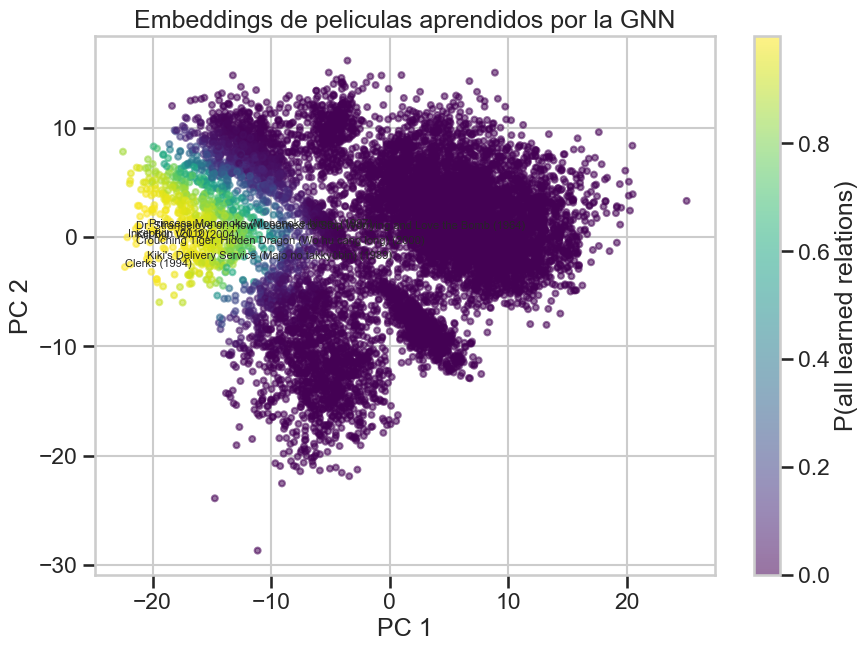

,title,genres,decade,avg_rating,cosine_similarity_to_target
50,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010,4.066,1.000
102,"Crouching Tiger, Hidden Dragon (Wo hu cang lon...",Action|Drama|Romance,2000,3.836,0.987
10,Fight Club (1999),Action|Crime|Drama|Thriller,1990,4.273,0.987
143,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,1960,4.268,0.987
35,Gladiator (2000),Action|Adventure|Drama,2000,3.938,0.986
41,Memento (2000),Mystery|Thriller,2000,4.123,0.984
130,Trainspotting (1996),Comedy|Crime|Drama,1990,4.039,0.983
71,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,2000,4.160,0.981
203,"Pan's Labyrinth (Laberinto del fauno, El) (2006)",Drama|Fantasy|Thriller,2000,3.815,0.979
14,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1990,4.238,0.978


In [166]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embedding_frame["x"],
    embedding_frame["y"],
    c=embedding_frame["joint_probability"],
    cmap="viridis",
    s=18,
    alpha=0.55,
)
highlight_titles = set(prediction_view["title"].head(7).tolist() + [target_title])
for _, row in embedding_frame.iterrows():
    if row["title"] in highlight_titles:
        plt.text(row["x"] + 0.02, row["y"] + 0.02, row["title"], fontsize=8)

plt.colorbar(scatter, label="P(all learned relations)")
plt.title("Embeddings de peliculas aprendidos por la GNN")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

similarity_frame = hetero_catalog[["title", "genres", "decade", "avg_rating"]].copy()
similarity_frame["cosine_similarity_to_target"] = embedding_sim
similarity_frame = similarity_frame.sort_values(
    "cosine_similarity_to_target", ascending=False
)

display(similarity_frame.head(12).round(3))

In [168]:
target_idx = target_index

In [169]:
embedding_neighbors = pd.DataFrame(
    {
        "movieId": hetero_catalog["movieId"],
        "title": hetero_catalog["title"],
        "genres": hetero_catalog["genres"],
        "decade": hetero_catalog["decade"],
        "avg_rating": hetero_catalog["avg_rating"],
        "embedding_similarity": embedding_sim,
    }
).sort_values("embedding_similarity", ascending=False)

In [170]:
normalized_feature_matrix = F.normalize(movie_feature_matrix, dim=1)

In [171]:
feature_sim = (
    (normalized_feature_matrix @ normalized_feature_matrix[target_idx])
    .detach()
    .cpu()
    .numpy()
)

In [172]:
feature_neighbors = pd.DataFrame(
    {
        "movieId": hetero_catalog["movieId"],
        "title": hetero_catalog["title"],
        "genres": hetero_catalog["genres"],
        "decade": hetero_catalog["decade"],
        "avg_rating": hetero_catalog["avg_rating"],
        "feature_similarity": feature_sim,
    }
).sort_values("feature_similarity", ascending=False)

In [173]:
print("Target:", target_title)
print("\nVecinos por embedding aprendido")
display(embedding_neighbors.head(12).round(3))
print("\nVecinos por features explicitas")
display(feature_neighbors.head(12).round(3))


Target: Inception (2010)

Vecinos por embedding aprendido


,movieId,title,genres,decade,avg_rating,embedding_similarity
50,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010,4.066,1.000
102,3996,"Crouching Tiger, Hidden Dragon (Wo hu cang lon...",Action|Drama|Romance,2000,3.836,0.987
10,2959,Fight Club (1999),Action|Crime|Drama|Thriller,1990,4.273,0.987
143,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,1960,4.268,0.987
35,3578,Gladiator (2000),Action|Adventure|Drama,2000,3.938,0.986
41,4226,Memento (2000),Mystery|Thriller,2000,4.123,0.984
130,778,Trainspotting (1996),Comedy|Crime|Drama,1990,4.039,0.983
71,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,2000,4.160,0.981
203,48394,"Pan's Labyrinth (Laberinto del fauno, El) (2006)",Drama|Fantasy|Thriller,2000,3.815,0.979
14,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1990,4.238,0.978



Vecinos por features explicitas


,movieId,title,genres,decade,avg_rating,feature_similarity
50,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010,4.066,1.000
241,109487,Interstellar (2014),Sci-Fi|IMAX,2010,3.993,0.777
810,104841,Gravity (2013),Action|Sci-Fi|IMAX,2010,3.578,0.773
755,85414,Source Code (2011),Action|Drama|Mystery|Sci-Fi|Thriller,2010,3.603,0.765
131,292,Outbreak (1995),Action|Drama|Sci-Fi|Thriller,1990,3.426,0.753
218,1625,"Game, The (1997)",Drama|Mystery|Thriller,1990,3.701,0.749
2165,150548,Sherlock: The Abominable Bride (2016),Action|Crime|Drama|Mystery|Thriller,2010,3.850,0.749
1198,72378,2012 (2009),Action|Drama|Sci-Fi|Thriller,2000,2.619,0.740
99,185,"Net, The (1995)",Action|Crime|Thriller,1990,3.040,0.740
444,88125,Harry Potter and the Deathly Hallows: Part 2 (...,Action|Adventure|Drama|Fantasy|Mystery|IMAX,2010,3.910,0.739


In [174]:
comparison_neighbors = (
    embedding_neighbors[["movieId", "title", "embedding_similarity"]]
    .merge(
        feature_neighbors[["movieId", "feature_similarity"]],
        on="movieId",
        how="left",
    )
    .merge(
        hetero_catalog[["movieId", "genres", "decade", "avg_rating"]],
        on="movieId",
        how="left",
    )
    .sort_values("embedding_similarity", ascending=False)
)

display(comparison_neighbors.head(15).round(3))

,movieId,title,embedding_similarity,feature_similarity,genres,decade,avg_rating
0,79132,Inception (2010),1.000,1.000,Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,2010,4.066
1,3996,"Crouching Tiger, Hidden Dragon (Wo hu cang lon...",0.987,0.652,Action|Drama|Romance,2000,3.836
2,2959,Fight Club (1999),0.987,0.711,Action|Crime|Drama|Thriller,1990,4.273
3,750,Dr. Strangelove or: How I Learned to Stop Worr...,0.987,0.577,Comedy|War,1960,4.268
4,3578,Gladiator (2000),0.986,0.678,Action|Adventure|Drama,2000,3.938
5,4226,Memento (2000),0.984,0.710,Mystery|Thriller,2000,4.123
6,778,Trainspotting (1996),0.983,0.655,Comedy|Crime|Drama,1990,4.039
7,7361,Eternal Sunshine of the Spotless Mind (2004),0.981,0.648,Drama|Romance|Sci-Fi,2000,4.160
8,48394,"Pan's Labyrinth (Laberinto del fauno, El) (2006)",0.979,0.694,Drama|Fantasy|Thriller,2000,3.815
9,50,"Usual Suspects, The (1995)",0.978,0.728,Crime|Mystery|Thriller,1990,4.238


Vamos a ver el grafo conectado con las predicciones del modelo para la película objetivo, utilizando tanto las relaciones simbólicas observadas como las relaciones neuronales aprendidas, y destacando las películas recomendadas, de alta calificación y populares según el modelo, para entender mejor cómo el modelo está utilizando la información del grafo para hacer sus predicciones.

In [175]:
graph_nodes = similarity_frame["title"].head(8).tolist()
subgraph = nx.Graph()

In [176]:
for title in graph_nodes:
    subgraph.add_node(title, highlight=(title == target_title))

selected_indices = [
    hetero_catalog.index[hetero_catalog["title"] == title][0] for title in graph_nodes
]

for i, left_idx in enumerate(selected_indices):
    for right_idx in selected_indices[i + 1 :]:
        weight = max(
            float(edge_weight_lookup.get((left_idx, right_idx), 0.0)),
            float(edge_weight_lookup.get((right_idx, left_idx), 0.0)),
        )
        if weight > 0:
            subgraph.add_edge(
                hetero_catalog.loc[left_idx, "title"],
                hetero_catalog.loc[right_idx, "title"],
                weight=weight,
            )

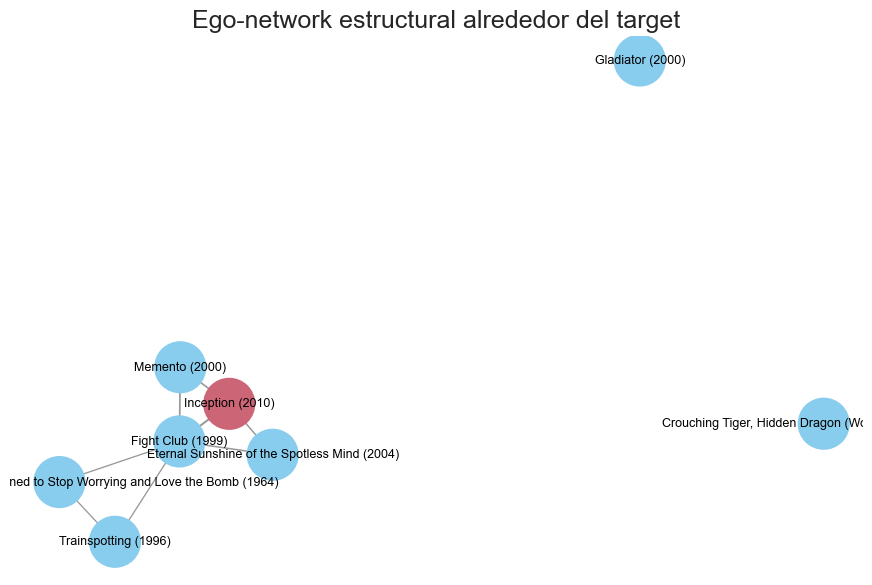

In [177]:
plt.figure(figsize=(11, 7))
positions = nx.spring_layout(subgraph, seed=42, weight="weight")
node_colors = [
    "#CC6677" if node == target_title else "#88CCEE" for node in subgraph.nodes
]
edge_widths = [0.8 + 0.35 * data["weight"] for _, _, data in subgraph.edges(data=True)]

nx.draw_networkx(
    subgraph,
    pos=positions,
    node_color=node_colors,
    node_size=1300,
    edge_color="#999999",
    width=edge_widths,
    font_size=9,
)

plt.title("Ego-network estructural alrededor del target")
plt.axis("off")
plt.show()

Esta comparación permite distinguir dos tipos de cercanía. La similitud por features explícitas refleja coincidencias observables, como género, década o tags. En cambio, la similitud en el embedding aprendido refleja cómo la GNN reorganiza esas películas según la estructura del grafo y las tareas objetivo. Por eso ambas listas no tienen por qué coincidir exactamente.

Entonces:
* si una película está alta en ambas listas, se parece al target también por metadata explícita
* si está alta en embedding pero no en features, la GNN la acercó por estructura y por tareas aprendidas

eso nos permite explicar que el embedding no es solo “similitud de género”, sino una representación aprendida para el problema


### Parser/QE

Ahora hacemos algo mas parecido a GNN-QE:

- extraemos una estructura logica desde texto,
- la pasamos a un AST,
- la compilamos a postfix,
- y la ejecutamos sobre el grafo completo, observado o hibrido.

El parser sigue siendo simple y por reglas, pero ya soporta:

- `AND`
- `OR`
- `NOT`
- géneros positivos y negativos
- década
- relaciones aprendidas `recommended`, `high_rating` y `popular`
- director, keyword, actor, writer, país, idioma y runtime bucket cuando esa metadata está disponible


In [178]:
def execute_postfix(tokens, relation_index, projector):
    # Esta función ejecuta una secuencia de tokens en notación postfija para calcular un vector de puntuaciones para las películas,
    # utilizando un índice de relaciones para las proyecciones simbólicas y una función de proyección que puede ser 
    # tanto simbólica como neuronal, y manteniendo un rastro detallado de cada paso de la ejecución para su análisis posterior.
    # El resultado final es el vector de puntuaciones resultante de ejecutar todos los tokens, 
    # junto con un DataFrame que documenta cada paso de la ejecución, las acciones realizadas y las películas principales en cada etapa.\
    stack = []
    trace = []

    for token in tokens:
        kind = token[0]

        if kind == "entity":
            _, node_type, value = token
            result = one_hot_set(node_type, value)
            stack.append(result)
            trace.append(
                {
                    "step": len(trace) + 1,
                    "action": f"anchor({node_type}:{value})",
                    "top_movies": f"anchor activo: {node_type}:{value}",
                }
            )
            continue

        if kind == "relation":
            _, relation_name = token
            source = stack.pop()
            result = projector(source, relation_name, relation_index)
            stack.append(result)
            trace.append(
                {
                    "step": len(trace) + 1,
                    "action": f"project({relation_name})",
                    "top_movies": summarize_scores(result),
                }
            )
            continue

        if kind == "op" and token[1] == "NOT":
            source = stack.pop()
            result = negation(source)
            stack.append(result)
            trace.append(
                {
                    "step": len(trace) + 1,
                    "action": "NOT",
                    "top_movies": summarize_scores(result),
                }
            )
            continue

        if kind == "op" and token[1] in {"AND", "OR"}:
            right = stack.pop()
            left = stack.pop()
            result = (
                conjunction(left, right)
                if token[1] == "AND"
                else disjunction(left, right)
            )
            stack.append(result)
            trace.append(
                {
                    "step": len(trace) + 1,
                    "action": token[1],
                    "top_movies": summarize_scores(result),
                }
            )
            continue

        raise ValueError(f"Token no soportado: {token}")

    return stack[0], pd.DataFrame(trace)

En la parte híbrida distinguimos dos tipos de proyección neuronal:

- una proyección multitarea sobre relaciones latentes como `recommended`, `high_rating` y `popular`,
- y un fallback neuronal para algunas relaciones del KG, en este caso `directed_by` y `has_keyword`.

Eso permite combinar información simbólica observada con enlaces plausibles propuestos por el modelo cuando el grafo observado es incompleto.


In [179]:
def normalize_text(text):
    text = (
        unicodedata.normalize("NFKD", text.lower())
        .encode("ascii", "ignore")
        .decode("ascii")
    )
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

In [180]:
GENRE_ALIASES = OrderedDict(
    [
        ("ciencia ficcion", "Sci-Fi"),
        ("sci fi", "Sci-Fi"),
        ("thriller", "Thriller"),
        ("crimen", "Crime"),
        ("crime", "Crime"),
        ("misterio", "Mystery"),
        ("aventura", "Adventure"),
        ("animacion", "Animation"),
        ("drama", "Drama"),
        ("comedia", "Comedy"),
    ]
)

GENRE_TO_PHRASE = {
    "Sci-Fi": "ciencia ficcion",
    "Thriller": "thriller",
    "Crime": "crimen",
    "Mystery": "misterio",
    "Adventure": "aventura",
    "Animation": "animacion",
    "Drama": "drama",
    "Comedy": "comedia",
}

DIRECTOR_ALIASES = OrderedDict()
ACTOR_ALIASES = OrderedDict()
WRITER_ALIASES = OrderedDict()
KEYWORD_ALIASES = OrderedDict()

In [181]:
if tmdb_enabled:
    if "director" in catalog.columns:
        for director_name in catalog["director"].dropna().astype(str).unique().tolist():
            normalized = normalize_text(director_name)
            if normalized:
                DIRECTOR_ALIASES[normalized] = director_name

    if "cast_names" in catalog.columns:
        ACTOR_ALIASES = OrderedDict(
            (normalize_text(name), name)
            for name, _ in Counter(
                actor
                for actors in catalog["cast_names"]
                if isinstance(actors, (list, tuple))
                for actor in actors
                if actor
            ).most_common(60)
            if normalize_text(name)
        )

    if "writer_names" in catalog.columns:
        WRITER_ALIASES = OrderedDict(
            (normalize_text(name), name)
            for name, _ in Counter(
                writer
                for writers in catalog["writer_names"]
                if isinstance(writers, (list, tuple))
                for writer in writers
                if writer
            ).most_common(40)
            if normalize_text(name)
        )

    if "tmdb_keywords" in catalog.columns:
        KEYWORD_ALIASES = OrderedDict(
            (normalize_text(name), name)
            for name, _ in Counter(
                keyword
                for keywords in catalog["tmdb_keywords"]
                if isinstance(keywords, (list, tuple))
                for keyword in keywords
                if keyword
            ).most_common(80)
            if normalize_text(name)
        )



In [182]:
LANGUAGE_ALIASES = OrderedDict(
    [
        ("ingles", "en"),
        ("espanol", "es"),
        ("frances", "fr"),
        ("japones", "ja"),
        ("coreano", "ko"),
    ]
)

COUNTRY_ALIASES = OrderedDict(
    [
        ("eeuu", "United States of America"),
        ("estados unidos", "United States of America"),
        ("reino unido", "United Kingdom"),
        ("francia", "France"),
        ("japon", "Japan"),
        ("corea del sur", "South Korea"),
    ]
)

RUNTIME_ALIASES = OrderedDict(
    [
        ("corta", "short"),
        ("corto", "short"),
        ("media", "medium"),
        ("larga", "long"),
        ("largo", "long"),
    ]
)

In [183]:
def anchor(node_type, value):
    # Esta función crea un token de ancla para un nodo dado su tipo y valor,
    # que se utilizará en la ejecución de la notación postfija para identificar nodos
    # específicos en el grafo, y asegurándose de que el valor se convierta a cadena para su uso consistente en la función de resolución de ID.
    return ("anchor", node_type, value)


def project(child, relation):
    # Esta función crea un token de proyección para una relación dada su nombre,
    # que se utilizará en la ejecución de la notación postfija para aplicar una proyección a través de esa relación,
    # y asegurándose de que el nombre de la relación se utilice de manera consistente
    # para identificar la relación en el índice de relaciones durante la ejecución.
    return ("project", relation, child)


def combine_with_operator(nodes, operator):
    # Esta función combina una lista de nodos utilizando un operador lógico dado (AND o OR),
    # aplicando el operador de manera secuencial a los nodos en la lista para
    # generar un nuevo vector de puntuaciones que representa la combinación lógica de los nodos,
    # y asegurándose de que el operador se aplique correctamente incluso si la lista de nodos tiene más de dos elementos.
    current = nodes[0]
    for node in nodes[1:]:
        current = operator(current, node)
    return current

In [184]:
def AND(left, right):
    return ("and", left, right)


def OR(left, right):
    return ("or", left, right)


def NOT(child):
    return ("not", child)

In [185]:
def extract_query(question):
    # Esta función extrae una consulta estructurada a partir de una pregunta en lenguaje natural,
    # normalizando el texto de la pregunta y buscando patrones específicos para identificar géneros, décadas
    # y otras características, y construyendo una representación de la consulta utilizando tokens de ancla, proyección y operadores lógicos,
    # que luego se puede ejecutar utilizando la función de ejecución de notación postfija para
    # generar un vector de puntuaciones para las películas que cumplen con los criterios especificados en la pregunta,
    # y asegurándose de manejar correctamente las negaciones y las combinaciones de criterios en la
    # consulta extraída.
    normalized = normalize_text(question)
    clauses = []

    positive_genres = []
    negative_genres = []
    for genre_alias, genre_name in GENRE_ALIASES.items():
        if genre_alias not in normalized:
            continue
        if f"no {genre_alias}" in normalized or f"sin {genre_alias}" in normalized:
            if genre_name not in negative_genres:
                negative_genres.append(genre_name)
        elif genre_name not in positive_genres:
            positive_genres.append(genre_name)

    if positive_genres:
        genre_nodes = [
            project(anchor("genre", genre_name), "rev_has_genre")
            for genre_name in positive_genres
        ]
        genre_operator = OR if " o " in normalized else AND
        clauses.append(
            combine_with_operator(genre_nodes, genre_operator)
            if len(genre_nodes) > 1
            else genre_nodes[0]
        )

    for genre_name in negative_genres:
        clauses.append(NOT(project(anchor("genre", genre_name), "rev_has_genre")))

    decade_match = re.search(r"decada de (\d{4})", normalized)
    if decade_match:
        clauses.append(
            project(
                anchor("decade", f"{decade_match.group(1)}s"), "rev_released_in_decade"
            )
        )
    # else:
    #     year_match = re.search(r"\b(?:del|de)\s+(\d{4})\b", normalized)
    #     if year_match:
    #         clauses.append(
    #             project(anchor("year", year_match.group(1)), "rev_released_in_year")
    #         )

    if any(
        fragment in normalized
        for fragment in ["recomendada", "recomendadas", "recommended"]
    ):
        clauses.append(
            project(
                anchor("anchor", TASK_SPECS["recommended"]["anchor"]),
                "rev_is_recommended",
            )
        )

    if any(
        fragment in normalized
        for fragment in ["bien puntuad", "alta puntuacion", "high rating"]
    ):
        clauses.append(
            project(
                anchor("anchor", TASK_SPECS["high_rating"]["anchor"]),
                "rev_is_high_rating",
            )
        )

    if any(
        fragment in normalized
        for fragment in ["popular", "populares", "muy vista", "muy vistas"]
    ):
        clauses.append(
            project(anchor("anchor", TASK_SPECS["popular"]["anchor"]), "rev_is_popular")
        )

    if tmdb_enabled:
        for director_alias, director_name in DIRECTOR_ALIASES.items():
            if f"de {director_alias}" in normalized:
                clauses.append(
                    project(anchor("director", director_name), "rev_directed_by")
                )
                break

    for keyword_alias, keyword_name in KEYWORD_ALIASES.items():
        if keyword_alias in normalized:
            clauses.append(project(anchor("keyword", keyword_name), "rev_has_keyword"))
            break

    for actor_alias, actor_name in ACTOR_ALIASES.items():
        if actor_alias in normalized:
            clauses.append(project(anchor("actor", actor_name), "rev_acted_by"))
            break

    for writer_alias, writer_name in WRITER_ALIASES.items():
        if writer_alias in normalized:
            clauses.append(project(anchor("writer", writer_name), "rev_written_by"))
            break

    for country_alias, country_name in COUNTRY_ALIASES.items():
        if country_alias in normalized:
            clauses.append(
                project(anchor("country", country_name), "rev_produced_in_country")
            )
            break

    for language_alias, language_code in LANGUAGE_ALIASES.items():
        if language_alias in normalized:
            clauses.append(
                project(anchor("language", language_code), "rev_original_language")
            )
            break

    for runtime_alias, runtime_bucket in RUNTIME_ALIASES.items():
        if runtime_alias in normalized:
            clauses.append(
                project(
                    anchor("runtime_bucket", runtime_bucket), "rev_has_runtime_bucket"
                )
            )
            break

    if not clauses:
        raise ValueError("No se pudo extraer una consulta util.")

    return combine_with_operator(clauses, AND) if len(clauses) > 1 else clauses[0]

In [ ]:
def ast_to_infix(node):
    # Esta función convierte un nodo de un árbol de sintaxis abstracta (AST) que representa una consulta estructurada en notación postfija
    # a una representación infija legible, utilizando una recursión para procesar cada tipo de nodo (ancla, proyección, operadores lógicos)
    # y generando una cadena que representa la consulta de manera más comprensible para los humanos,
    # asegurándose de manejar correctamente la precedencia de los operadores y la estructura del árbol.

    kind = node[0]
    if kind == "anchor":
        _, node_type, value = node
        return f"{node_type}:{value}"
    if kind == "project":
        return f"{node[1]}({ast_to_infix(node[2])})"
    if kind == "and":
        return f"({ast_to_infix(node[1])} AND {ast_to_infix(node[2])})"
    if kind == "or":
        return f"({ast_to_infix(node[1])} OR {ast_to_infix(node[2])})"
    if kind == "not":
        return f"NOT({ast_to_infix(node[1])})"
    raise ValueError(f"Nodo desconocido: {kind}")


def to_postfix(node):
    # Esta función convierte un nodo de un árbol de sintaxis abstracta (AST) que representa una consulta estructurada en notación postfija,
    # utilizando una recursión para procesar cada tipo de nodo (ancla, proyección, operadores lógicos) 
    # y generando una lista de tokens en notación postfija que se puede ejecutar utilizando la función de ejecución de notación postfija,
    # asegurándose de manejar correctamente la estructura del árbol y el orden de los operadores 
    # para generar la secuencia de tokens adecuada para la ejecución.
    kind = node[0]
    if kind == "anchor":
        _, node_type, value = node
        return [("entity", node_type, value)]
    if kind == "project":
        return to_postfix(node[2]) + [("relation", node[1])]
    if kind == "and":
        return to_postfix(node[1]) + to_postfix(node[2]) + [("op", "AND")]
    if kind == "or":
        return to_postfix(node[1]) + to_postfix(node[2]) + [("op", "OR")]
    if kind == "not":
        return to_postfix(node[1]) + [("op", "NOT")]
    raise ValueError(f"Nodo desconocido: {kind}")


def pretty_token(token):
    # Esta función convierte un token de la notación postfija en una representación legible para los humanos,
    # utilizando el tipo del token para determinar cómo formatearlo, y generando una cadena 
    # que representa el token de manera comprensible, lo que es útil para documentar y analizar la secuencia de tokens 
    # durante la ejecución de la consulta estructurada, y asegurándose de manejar correctamente 
    # cada tipo de token para generar una representación clara.
    kind = token[0]
    if kind == "entity":
        _, node_type, value = token
        return f"{node_type}:{value}"
    _, value = token
    return value if kind != "op" else value.lower()

In [187]:
genre_phrase = " y ".join(
    GENRE_TO_PHRASE.get(genre, genre.lower()) for genre in primary_genres
)

In [188]:
main_question = (
    f"¿Que peliculas de {genre_phrase} recomendadas, bien puntuadas y populares "
    f"de la decada de {target_decade}?"
)

In [189]:
main_ast = extract_query(main_question)
main_postfix = to_postfix(main_ast)

In [190]:
print("Pregunta principal:", main_question)
print("Forma logica:", ast_to_infix(main_ast))
print("Postfix:", " -> ".join(pretty_token(token) for token in main_postfix))

Pregunta principal: ¿Que peliculas de ciencia ficcion y thriller recomendadas, bien puntuadas y populares de la decada de 2010?
Forma logica: (((((rev_has_genre(genre:Sci-Fi) AND rev_has_genre(genre:Thriller)) AND rev_released_in_decade(decade:2010s)) AND rev_is_recommended(anchor:Recommended)) AND rev_is_high_rating(anchor:HighRating)) AND rev_is_popular(anchor:Popular))
Postfix: genre:Sci-Fi -> rev_has_genre -> genre:Thriller -> rev_has_genre -> and -> decade:2010s -> rev_released_in_decade -> and -> anchor:Recommended -> rev_is_recommended -> and -> anchor:HighRating -> rev_is_high_rating -> and -> anchor:Popular -> rev_is_popular -> and


Expansdimos las consultas: **AND, OR y NOT**

No nos quedamos con una sola consulta. Armamos tres vistas:

1. una consulta fuerte con `AND` sobre filtros simbolicos y relaciones aprendidas,
2. una consulta mas flexible con `OR` entre relaciones aprendidas,
3. una consulta con `NOT` para excluir un genero.

Eso permite mostrar con mas claridad que parte es simbolica y que parte es neuronal.

In [191]:
def combine_and(nodes):
    return combine_with_operator(nodes, AND) if len(nodes) > 1 else nodes[0]

In [192]:
negative_genre = "Animation" if "Animation" in all_genres else all_genres[0]
genre_constraints = [
    project(anchor("genre", genre_name), "rev_has_genre")
    for genre_name in primary_genres
]
base_filters = genre_constraints + [
    project(anchor("decade", f"{target_decade}s"), "rev_released_in_decade")
]

In [193]:
query_suite = OrderedDict(
    [
        (
            "Q1 - AND fuerte",
            combine_and(
                base_filters
                + [
                    project(
                        anchor("anchor", TASK_SPECS["recommended"]["anchor"]),
                        "rev_is_recommended",
                    ),
                    project(
                        anchor("anchor", TASK_SPECS["high_rating"]["anchor"]),
                        "rev_is_high_rating",
                    ),
                    project(
                        anchor("anchor", TASK_SPECS["popular"]["anchor"]),
                        "rev_is_popular",
                    ),
                ]
            ),
        ),
        (
            "Q2 - OR entre relaciones aprendidas",
            AND(
                combine_and(base_filters),
                OR(
                    OR(
                        project(
                            anchor("anchor", TASK_SPECS["recommended"]["anchor"]),
                            "rev_is_recommended",
                        ),
                        project(
                            anchor("anchor", TASK_SPECS["high_rating"]["anchor"]),
                            "rev_is_high_rating",
                        ),
                    ),
                    project(
                        anchor("anchor", TASK_SPECS["popular"]["anchor"]),
                        "rev_is_popular",
                    ),
                ),
            ),
        ),
        (
            f"Q3 - Popular y no {negative_genre}",
            AND(
                project(
                    anchor("anchor", TASK_SPECS["popular"]["anchor"]),
                    "rev_is_popular",
                ),
                NOT(project(anchor("genre", negative_genre), "rev_has_genre")),
            ),
        ),
    ]
)

In [194]:
def run_query_case(ast):
    # Esta función ejecuta un caso de consulta dado su árbol de sintaxis abstracta (AST) utilizando tanto
    # la proyección simbólica basada en el índice de relaciones como la proyección neuronal aprendida del modelo de GNN,
    # generando un vector de puntuaciones para las películas utilizando ambas proyecciones,
    # y luego combinando los resultados para comparar el desempeño de cada enfoque, y documentando cada paso de la 
    # ejecución en un DataFrame para su análisis posterior, asegurándose de manejar correctamente la estructura del AST 
    # y las proyecciones para generar resultados comparables.
    postfix = to_postfix(ast)
    symbolic_full_scores, symbolic_full_trace = execute_postfix(
        postfix, relation_index_full, projector=symbolic_project
    )
    symbolic_observed_scores, symbolic_observed_trace = execute_postfix(
        postfix, relation_index_observed, projector=symbolic_project
    )
    hybrid_scores, hybrid_trace = execute_postfix(
        postfix, relation_index_observed, projector=hybrid_project
    )

    rows = []
    for movie_global_id, movie_label in zip(movie_global_ids, movie_display_labels):
        rows.append(
            {
                "movie": movie_label,
                "Simbolico completo": float(symbolic_full_scores[movie_global_id]),
                "Simbolico observado": float(symbolic_observed_scores[movie_global_id]),
                "Hibrido GNN-QE": float(hybrid_scores[movie_global_id]),
            }
        )

    comparison_df = pd.DataFrame(rows).set_index("movie")
    comparison_df = comparison_df.loc[comparison_df.max(axis=1) >= 0.03].sort_values(
        "Hibrido GNN-QE", ascending=False
    )

    target_movie_global_id = node_lookup[("movie", int(target_row["movieId"]))]
    return {
        "ast": ast,
        "postfix": postfix,
        "comparison": comparison_df,
        "symbolic_full_trace": symbolic_full_trace,
        "symbolic_observed_trace": symbolic_observed_trace,
        "hybrid_trace": hybrid_trace,
        "target_full": float(symbolic_full_scores[target_movie_global_id]),
        "target_observed": float(symbolic_observed_scores[target_movie_global_id]),
        "target_hybrid": float(hybrid_scores[target_movie_global_id]),
    }

In [195]:
query_results = OrderedDict()
summary_rows = []
for query_name, ast in query_suite.items():
    result = run_query_case(ast)
    query_results[query_name] = result
    top_movies = result["comparison"].head(5).index.tolist()
    summary_rows.append(
        {
            "Query": query_name,
            "Logica": ast_to_infix(ast),
            "Target completo": round(result["target_full"], 3),
            "Target observado": round(result["target_observed"], 3),
            "Target hibrido": round(result["target_hybrid"], 3),
            "Top hybrid": ", ".join(top_movies) if top_movies else "sin candidatos",
        }
    )

In [196]:
summary_df = pd.DataFrame(summary_rows)


In [197]:
display(summary_df)

,Query,Logica,Target completo,Target observado,Target hibrido,Top hybrid
0,Q1 - AND fuerte,(((((rev_has_genre(genre:Sci-Fi) AND rev_has_g...,1.0,0.0,0.999,"Mad Max: Fury Road (2015), X-Men: First Class ..."
1,Q2 - OR entre relaciones aprendidas,(((rev_has_genre(genre:Sci-Fi) AND rev_has_gen...,1.0,0.0,1.000,"The Hunger Games (2012), Iron Man 2 (2010), Ma..."
2,Q3 - Popular y no Animation,(rev_is_popular(anchor:Popular) AND NOT(rev_ha...,1.0,0.0,1.000,"Proof of Life (2000), Living Daylights, The (1..."


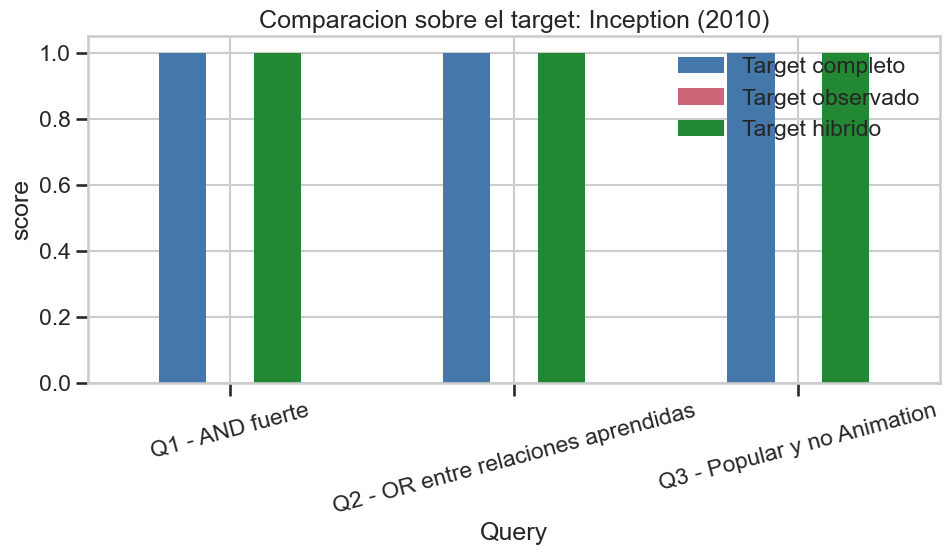

In [198]:
target_summary = summary_df.set_index("Query")[["Target completo", "Target observado", "Target hibrido"]]
target_summary.plot(kind="bar", figsize=(11, 4.5), color=["#4477AA", "#CC6677", "#228833"], rot=15)
plt.ylim(0, 1.05)
plt.ylabel("score")
plt.title(f"Comparacion sobre el target: {target_title}")
plt.show()

In [199]:
main_result = query_results["Q1 - AND fuerte"]

In [200]:
print("Pregunta principal:", main_question)
print("Logica Q1:", ast_to_infix(query_suite["Q1 - AND fuerte"]))
print("Postfix Q1:", " -> ".join(pretty_token(token) for token in main_result["postfix"]))

Pregunta principal: ¿Que peliculas de ciencia ficcion y thriller recomendadas, bien puntuadas y populares de la decada de 2010?
Logica Q1: (((((rev_has_genre(genre:Sci-Fi) AND rev_has_genre(genre:Thriller)) AND rev_released_in_decade(decade:2010s)) AND rev_is_recommended(anchor:Recommended)) AND rev_is_high_rating(anchor:HighRating)) AND rev_is_popular(anchor:Popular))
Postfix Q1: genre:Sci-Fi -> rev_has_genre -> genre:Thriller -> rev_has_genre -> and -> decade:2010s -> rev_released_in_decade -> and -> anchor:Recommended -> rev_is_recommended -> and -> anchor:HighRating -> rev_is_high_rating -> and -> anchor:Popular -> rev_is_popular -> and


Esta consulta ya mezcla dos tipos de razonamiento. Por un lado, incluye restricciones simbólicas observables en el knowledge graph, como género y década. Por otro, incorpora relaciones aprendidas por la GNN, como recomendación, alta valoración y popularidad. La forma postfix permite ejecutar esa lógica de manera secuencial sobre el grafo.


In [201]:
display(main_result["comparison"].head(10).round(3))

,Simbolico completo,Simbolico observado,Hibrido GNN-QE
movie,,,
Mad Max: Fury Road (2015),1.0,1.0,1.000
X-Men: First Class (2011),1.0,1.0,1.000
Limitless (2011),1.0,1.0,1.000
The Hunger Games: Mockingjay - Part 1 (2014),1.0,1.0,1.000
Ex Machina (2015),1.0,1.0,1.000
"Cabin in the Woods, The (2012)",1.0,1.0,1.000
Inception (2010),1.0,0.0,0.999
Captain America: The First Avenger (2011),0.0,0.0,0.352
Iron Man 3 (2013),0.0,0.0,0.264


In [202]:
display(main_result["hybrid_trace"])

,step,action,top_movies
0,1,anchor(genre:Sci-Fi),anchor activo: genre:Sci-Fi
1,2,project(rev_has_genre),"Matrix, The (1999): 1.000, Star Wars: Episode ..."
2,3,anchor(genre:Thriller),anchor activo: genre:Thriller
3,4,project(rev_has_genre),"Pulp Fiction (1994): 1.000, Silence of the Lam..."
4,5,AND,"Matrix, The (1999): 1.000, Jurassic Park (1993..."
5,6,anchor(decade:2010s),anchor activo: decade:2010s
6,7,project(rev_released_in_decade),"Inception (2010): 1.000, Dark Knight Rises, Th..."
7,8,AND,"Inception (2010): 1.000, The Hunger Games (201..."
8,9,anchor(anchor:Recommended),anchor activo: anchor:Recommended
9,10,project(rev_is_recommended),"Forrest Gump (1994): 1.000, Shawshank Redempti..."


In [203]:
for query_name in [name for name in query_suite if name != "Q1 - AND fuerte"]:
    print(query_name)
    display(query_results[query_name]["comparison"].head(10).round(3))

Q2 - OR entre relaciones aprendidas


,Simbolico completo,Simbolico observado,Hibrido GNN-QE
movie,,,
The Hunger Games (2012),1.0,1.0,1.0
Iron Man 2 (2010),1.0,1.0,1.0
Mad Max: Fury Road (2015),1.0,1.0,1.0
X-Men: First Class (2011),1.0,1.0,1.0
Iron Man 3 (2013),1.0,1.0,1.0
Source Code (2011),1.0,1.0,1.0
Captain America: The First Avenger (2011),1.0,1.0,1.0
Limitless (2011),1.0,1.0,1.0
Maximum Ride (2016),1.0,1.0,1.0


Q3 - Popular y no Animation


,Simbolico completo,Simbolico observado,Hibrido GNN-QE
movie,,,
Proof of Life (2000),1.0,1.0,1.0
"Living Daylights, The (1987)",1.0,1.0,1.0
"Celebration, The (Festen) (1998)",1.0,1.0,1.0
State and Main (2000),1.0,1.0,1.0
Flirting With Disaster (1996),1.0,1.0,1.0
Beauty of the Day (Belle de jour) (1967),1.0,1.0,1.0
Speed (1994),1.0,1.0,1.0
Back to the Future (1985),1.0,1.0,1.0
Twelve Monkeys (a.k.a. 12 Monkeys) (1995),1.0,1.0,1.0


Ahora:

1. El target necesita satisfacer filtros simbolicos y varias relaciones aprendidas al mismo tiempo.
2. En el grafo observado, esas relaciones desaparecen porque ocultamos sus enlaces positivos.
3. En el sistema hibrido, la GNN vuelve a asignar probabilidad a esas relaciones faltantes a partir de la estructura del grafo.
4. Al cambiar la forma logica de la consulta, por ejemplo usando `AND`, `OR` o `NOT`, cambia tambien la dificultad de recuperar correctamente el target.
5. Esto permite ver que Query Execution no depende solo de la informacion simbolica observada, sino tambien de la capacidad del modelo para reconstruir enlaces plausibles.


Si TMDb esta activo y el target tiene director conocido, agregamos una restriccion extra
para mostrar una consulta todavia mas especifica.

In [204]:
if tmdb_enabled and pd.notna(target_row.get("director")):
    director_question = (
        f"¿Que peliculas de {genre_phrase} recomendadas y bien puntuadas "
        f"de la decada de {target_decade} de {target_row['director']}?"
    )
    director_ast = extract_query(director_question)
    director_result = run_query_case(director_ast)

    print("Pregunta:", director_question)
    print("Forma logica:", ast_to_infix(director_ast))
    display(director_result["comparison"].head(10).round(3))
    display(director_result["hybrid_trace"])
else:
    print("TMDb no esta activo o no hay director disponible. Esta seccion se omite.")

Pregunta: ¿Que peliculas de ciencia ficcion y thriller recomendadas y bien puntuadas de la decada de 2010 de Christopher Nolan?
Forma logica: (((((rev_has_genre(genre:Sci-Fi) AND rev_has_genre(genre:Thriller)) AND rev_released_in_decade(decade:2010s)) AND rev_is_recommended(anchor:Recommended)) AND rev_is_high_rating(anchor:HighRating)) AND rev_directed_by(director:Christopher Nolan))


,Simbolico completo,Simbolico observado,Hibrido GNN-QE
movie,,,
Inception (2010),1.0,0.0,0.999
X-Men: First Class (2011),0.0,0.0,0.988
Mad Max: Fury Road (2015),0.0,0.0,0.987
Predestination (2014),0.0,0.0,0.973
Ex Machina (2015),0.0,0.0,0.934
Annihilation (2018),0.0,0.0,0.849
"Cabin in the Woods, The (2012)",0.0,0.0,0.835
Limitless (2011),0.0,0.0,0.749
The Hunger Games: Mockingjay - Part 1 (2014),0.0,0.0,0.625


,step,action,top_movies
0,1,anchor(genre:Sci-Fi),anchor activo: genre:Sci-Fi
1,2,project(rev_has_genre),"Matrix, The (1999): 1.000, Star Wars: Episode ..."
2,3,anchor(genre:Thriller),anchor activo: genre:Thriller
3,4,project(rev_has_genre),"Pulp Fiction (1994): 1.000, Silence of the Lam..."
4,5,AND,"Matrix, The (1999): 1.000, Jurassic Park (1993..."
5,6,anchor(decade:2010s),anchor activo: decade:2010s
6,7,project(rev_released_in_decade),"Inception (2010): 1.000, Dark Knight Rises, Th..."
7,8,AND,"Inception (2010): 1.000, The Hunger Games (201..."
8,9,anchor(anchor:Recommended),anchor activo: anchor:Recommended
9,10,project(rev_is_recommended),"Forrest Gump (1994): 1.000, Shawshank Redempti..."


### Cierre

Capturamos la idea central del enfoque en una forma explicable y manipulable.

Trabajamos con un knowledge graph construido a partir de MovieLens y TMDb, un modelo relacional simplificado sobre un grafo heterogéneo, un parser por reglas para transformar preguntas en consultas lógicas y un motor de ejecución híbrido que combina razonamiento simbólico con proyecciones neuronales.

Eso nos permite mostrar, en un mismo pipeline:

- cómo representar conocimiento como grafo,
- cómo aprender relaciones faltantes con una GNN,
- cómo traducir una pregunta a una forma lógica,
- y cómo ejecutar esa consulta sobre un grafo incompleto.

La simplificación no elimina lo importante: al contrario, hace visible el mecanismo (cómo se conectan conocimiento estructurado, aprendizaje sobre grafos y ejecución de consultas).



### Referencias

![gnn-qe](./Images/gnn-qe.png)

* https://github.com/DeepGraphLearning/GNN-QE

![Lenguaje Matemático](./Images/Matematicas.png)

![Contacto](./Images/Contacto.png)